# Интернет-магазин «В один клик»

# План проекта:
* 1) Загрузка данных и первичный осмотр данных.
** Загрузим и детально рассмотрим все датасеты, построим несколько графиков, первоначальные статистические данные о характере значений датасета, типы столбцов и их название, сопостам то как описал данные заказчик и, что находится там фактически.
* 2) Предобработка данных.
** Проверим на наличие дубликатов, пропусков и избавимся от них если они присутствуют, соответствует ли оформление столбцов нужному регистру. Посмотрим все ли данные в нужном виде, если нет, то подкорректируем их.
* 3) Исследовательский анализ данных
** Построим графики для каждого признака. Сделаем выводы о данных, заметим ли мы  выбросы, необычное распределение количественных признаков или другие особенности, сможем ли мы улучшить данные и нуждаемся ли мы в этом.
* 4) Объединение таблиц
* 5) Коррелляционный анализ
** Корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования. Сделаем выводы о мультиколлинеарности и при необходимости устраните её.
* 6) Использование пайплайнов
* 7) Анализ важности признаков
** Оценим важность признаков для лучшей модели и построем график важности с помощью метода SHAP. 
** Сделайем выводы о значимости признаков:
*** какие признаки мало значимы для модели;
*** какие признаки сильнее всего влияют на целевой признак;
*** как можно использовать эти наблюдения при моделировании и принятии бизнес-решений.
* 8) сегментация покупателей
** Выполним сегментацию покупателей. Используйте результаты моделирования и данные о прибыльности покупателей.
**  Выберем группу покупателей и предложим, как увеличить её покупательскую активность: 
** Проведём графическое и аналитическое исследование группы покупателей.
** Сделаем предложения по работе с сегментом для увеличения покупательской активности.
** Сделаем выводы о сегментах
* 9) Итоговый вывод

## Загрузка данных

### Для начала импортируем нужные библеотеки которые нам пригодятся.

In [1]:
!pip install scikit-learn==1.1.3 -q
!pip install phik --upgrade -q
!pip install optuna -q
!pip install optuna-integration -q
!pip install shap -q


In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import shap
from scipy import stats as st
import phik
from phik import resources, report

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    f_regression,
    mutual_info_classif,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    SGDRegressor,
)
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    train_test_split,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
    LabelEncoder,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from optuna import distributions
from optuna.integration import OptunaSearchCV
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 20000)
pd.set_option('max_colwidth', 1000)

### Теперь приступим к первичному осмотру данных
Создадим функцию которая будет выводить всю информацию о датафрейме

In [7]:
def general_information(data):
    display(data.info())
    display(data.head(5))
    display(data.describe().T)
    if not data.select_dtypes(include='object').empty:
        description = data.describe(include='object')
        display(description)

    if data.select_dtypes(include=[np.number]).columns.size > 0:
        display(data.hist(figsize=(15, 8)));
        plt.show()
    else:
        print("Нет числовых данных для визуализации.")


Непосредственно загрузим датасеты

In [8]:
market_file = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\Анализ пользовательской активности\market_file (1).csv", decimal = ',')
market_money = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\Анализ пользовательской активности\market_money (1).csv", decimal = ',')
market_time = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\Анализ пользовательской активности\market_time (1).csv", decimal = ',')
money = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\Анализ пользовательской активности\money (1).csv", decimal = ',')

### Осмотрим первый датасет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   id                                   1300 non-null   int64 
 1   Покупательская активность            1300 non-null   object
 2   Тип сервиса                          1300 non-null   object
 3   Разрешить сообщать                   1300 non-null   object
 4   Маркет_актив_6_мес                   1300 non-null   object
 5   Маркет_актив_тек_мес                 1300 non-null   int64 
 6   Длительность                         1300 non-null   int64 
 7   Акционные_покупки                    1300 non-null   object
 8   Популярная_категория                 1300 non-null   object
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64 
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64 
 11  Ошибка_сервиса                       1300 n

None

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.0,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.0,215672.75,215997.5,216322.25,216647.0
Маркет_актив_тек_мес,1300.0,4.011538,0.696868,3.0,4.00,4.0,4.00,5.0
Длительность,1300.0,601.898462,249.856289,110.0,405.50,606.0,806.00,1079.0
Средний_просмотр_категорий_за_визит,1300.0,3.270000,1.355350,1.0,2.00,3.0,4.00,6.0
Неоплаченные_продукты_штук_квартал,1300.0,2.840000,1.971451,0.0,1.00,3.0,4.00,10.0
Ошибка_сервиса,1300.0,4.185385,1.955298,0.0,3.00,4.0,6.00,9.0
Страниц_за_визит,1300.0,8.176923,3.978126,1.0,5.00,8.0,11.00,20.0


,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Акционные_покупки,Популярная_категория
count,1300,1300,1300,1300,1300,1300
unique,2,3,2,41,42,6
top,Прежний уровень,стандарт,да,4.1,0.24,Товары для детей
freq,802,914,962,94,93,330


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'Маркет_актив_тек_мес'}>,
        <Axes: title={'center': 'Длительность'}>],
       [<Axes: title={'center': 'Средний_просмотр_категорий_за_визит'}>,
        <Axes: title={'center': 'Неоплаченные_продукты_штук_квартал'}>,
        <Axes: title={'center': 'Ошибка_сервиса'}>],
       [<Axes: title={'center': 'Страниц_за_визит'}>, <Axes: >, <Axes: >]],
      dtype=object)

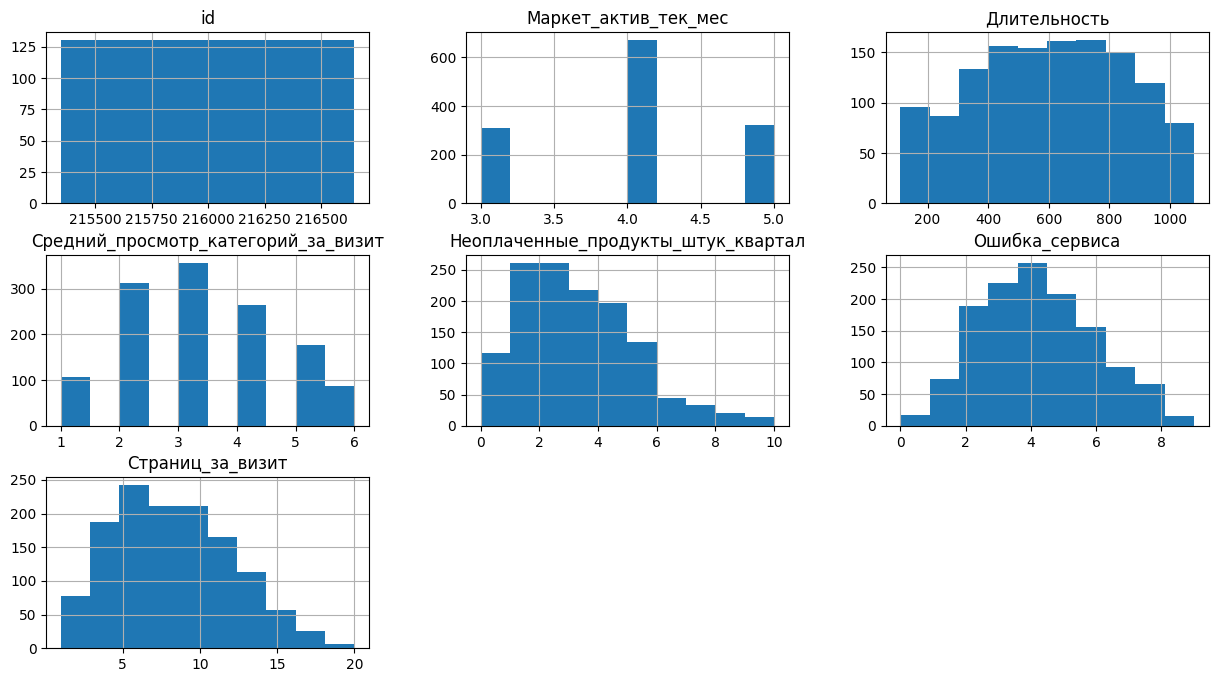

In [9]:
general_information(market_file)

Анализируя первично первый датасет мы можем заметить:
- Видимых пропусков не обнаружено (могут быть в виде строк)
- Столбцы на русском языке
- Маркет_актив_6_мес, Акционные_покупки присвоен тип обьект, в строках замечены цифры, анализ этих столбцов как категориальных показывает тоже числовые значения
- Стандартное отклоние Длительности сильно отличается от стандартного откланения других столбцов 
- Медиана значений столбцов не сильно отличается от среднего значения 
- Меркет актив тек мес все значения делятся на 3 группы с рейтингом по убыванию групп 4, 5, 3 
- Длительность и Ошибка_сервиса распределяются нормально, видим некоторое увелечение длительности возле 0 у длительности
- Средний_просмотр_категорий_за_визит, в целом выглядит нормально, если бы не одно но, распределение значений от 5 до 6 выглядит очень странно, нужно получше рассмотреть значения
- В оставшихся признаках распределение близкое к нормальному с небольшим смещением влево

### Приступим ко второму датасету

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       3900 non-null   int64 
 1   Период   3900 non-null   object
 2   Выручка  3900 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.5+ KB


None

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


,count,mean,std,min,25%,50%,75%,max
id,3900.0,215997.5,375.325686,215348.0,215672.75,215997.5,216322.25,216647.0


,Период,Выручка
count,3900,3900
unique,3,2776
top,препредыдущий_месяц,4729.0
freq,1300,8


array([[<Axes: title={'center': 'id'}>]], dtype=object)

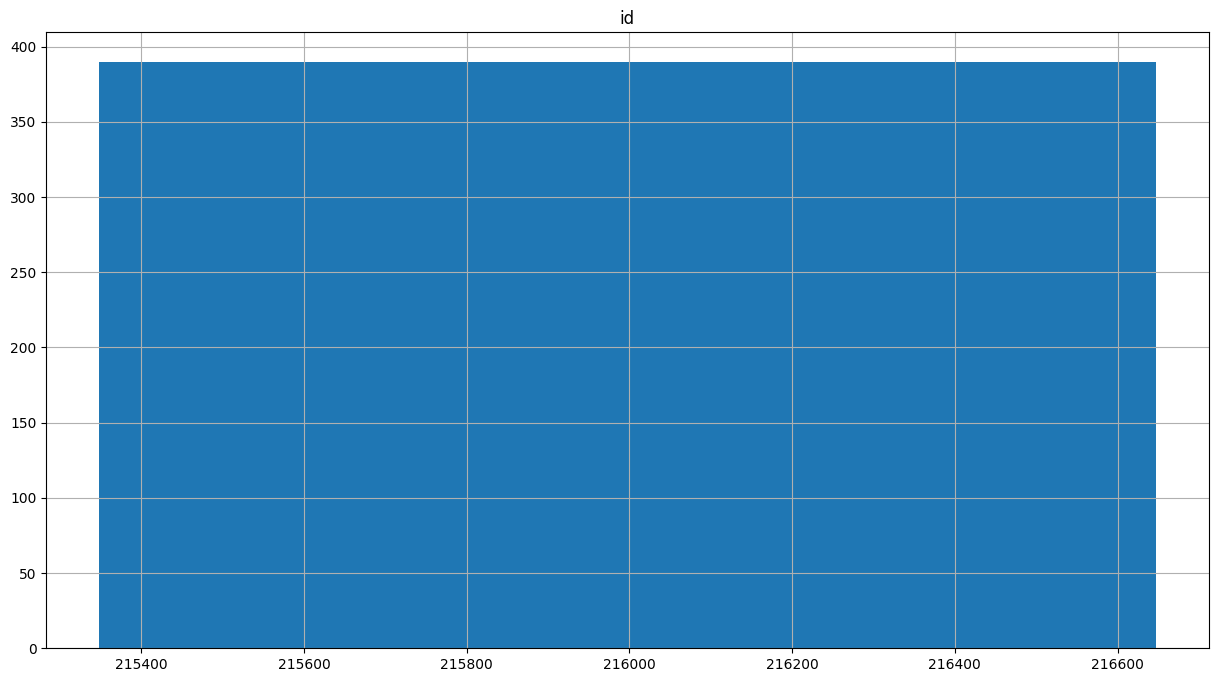

In [10]:
general_information(market_money)

Анализируя первично второй датасет мы можем заметить:
- Выручка имеет тип столбца обькт что не является корректным
- в Периоде имеется три значения, текущий_месяц, предыдущий_месяц, препредыдущий_месяц
- Выручка прописана для всех периодов, если она равна 0, значит она равна 0, это не пропуск
- Диаграмму для столбца Выручка не получится построить из-за неподходящего типа столбца, исследуем этот момент далее более детально

### Перейдём наконец к третьему датасету

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


None

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


,count,mean,std,min,25%,50%,75%,max
id,2600.0,215997.500000,375.349754,215348.0,215672.75,215997.5,216322.25,216647.0
минут,2600.0,13.336154,4.080198,4.0,10.00,13.0,16.00,23.0


,Период
count,2600
unique,2
top,текущий_месяц
freq,1300


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'минут'}>]], dtype=object)

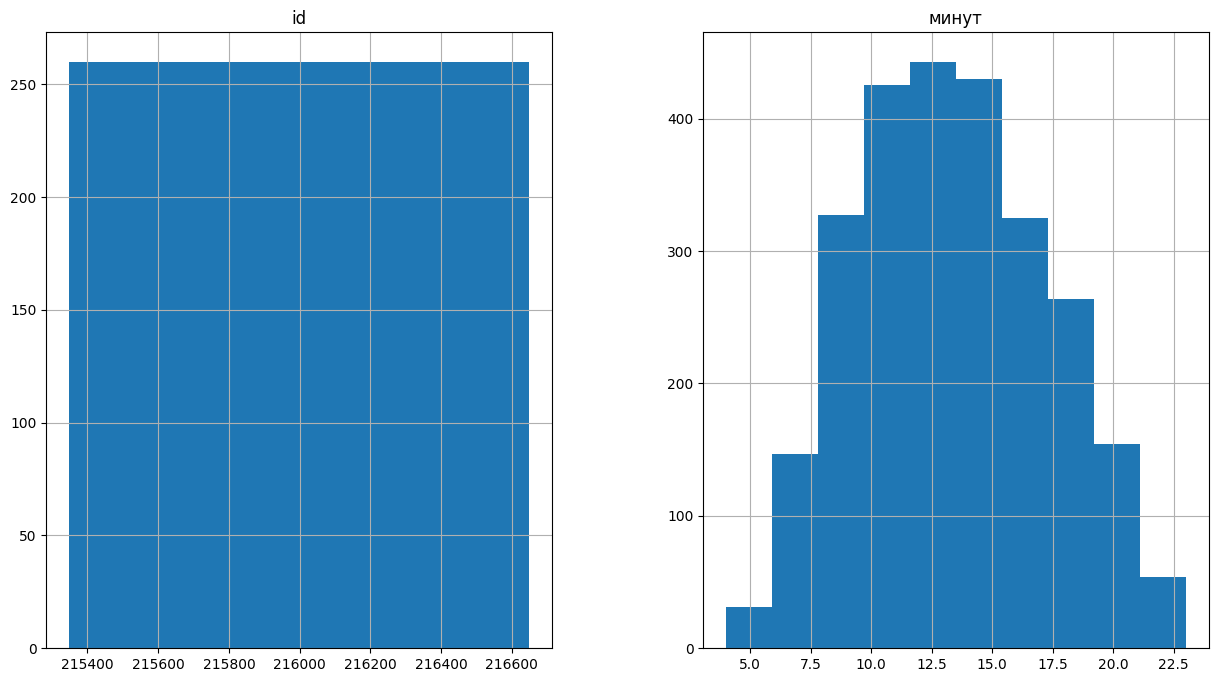

In [11]:
general_information(market_time)

Наблюдения:
- Столбцы имеют корректный тип столбцов 
- Прибыль распределяется нормально
- Период имеет только два значения, текущий_месяц и предыдцщий_месяц, причём вероятно с опечаткой или это выявленая проблема с сбором информации у заказчика, соотношение значений 50/50

### И наконец заключительный датасет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


None

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.00,215672.75,215997.500,216322.25,216647.00
Прибыль,1300.0,3.996631,1.013722,0.86,3.30,4.045,4.67,7.43


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'Прибыль'}>]], dtype=object)

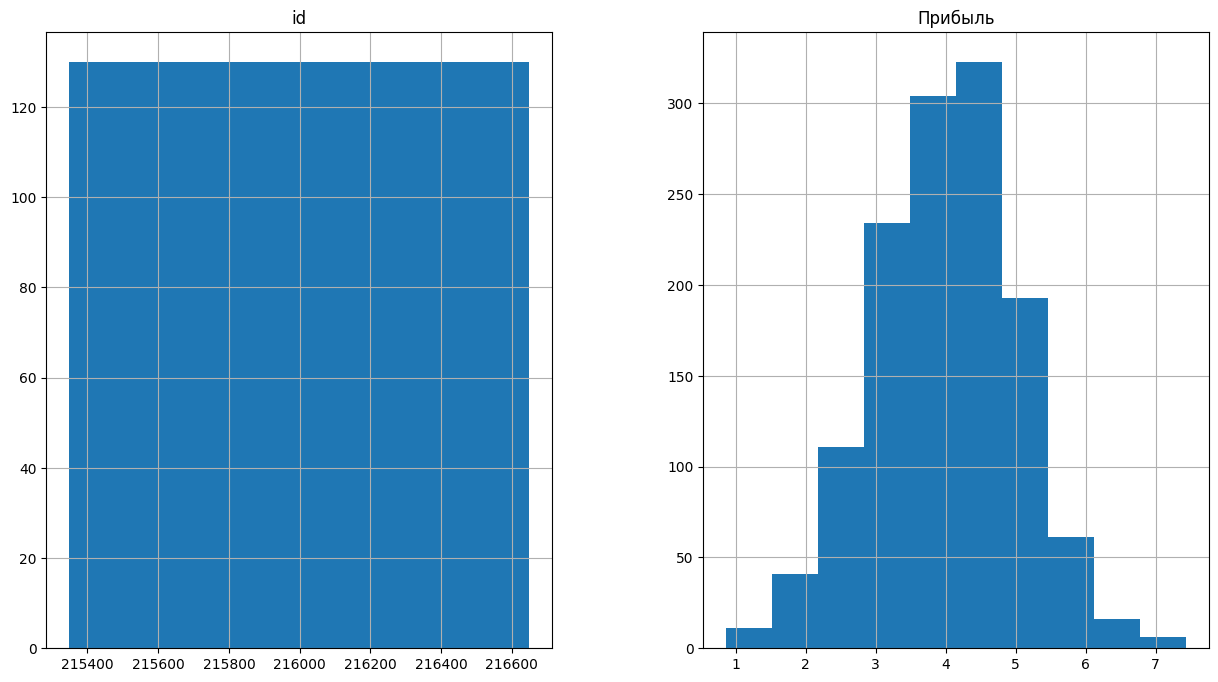

In [16]:
general_information(money)

Видем не правильныую загрузку датасета, загрузим по другому

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


None

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


,count,mean,std,min,25%,50%,75%,max
id,1300.0,215997.500000,375.421985,215348.00,215672.75,215997.500,216322.25,216647.00
Прибыль,1300.0,3.996631,1.013722,0.86,3.30,4.045,4.67,7.43


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'Прибыль'}>]], dtype=object)

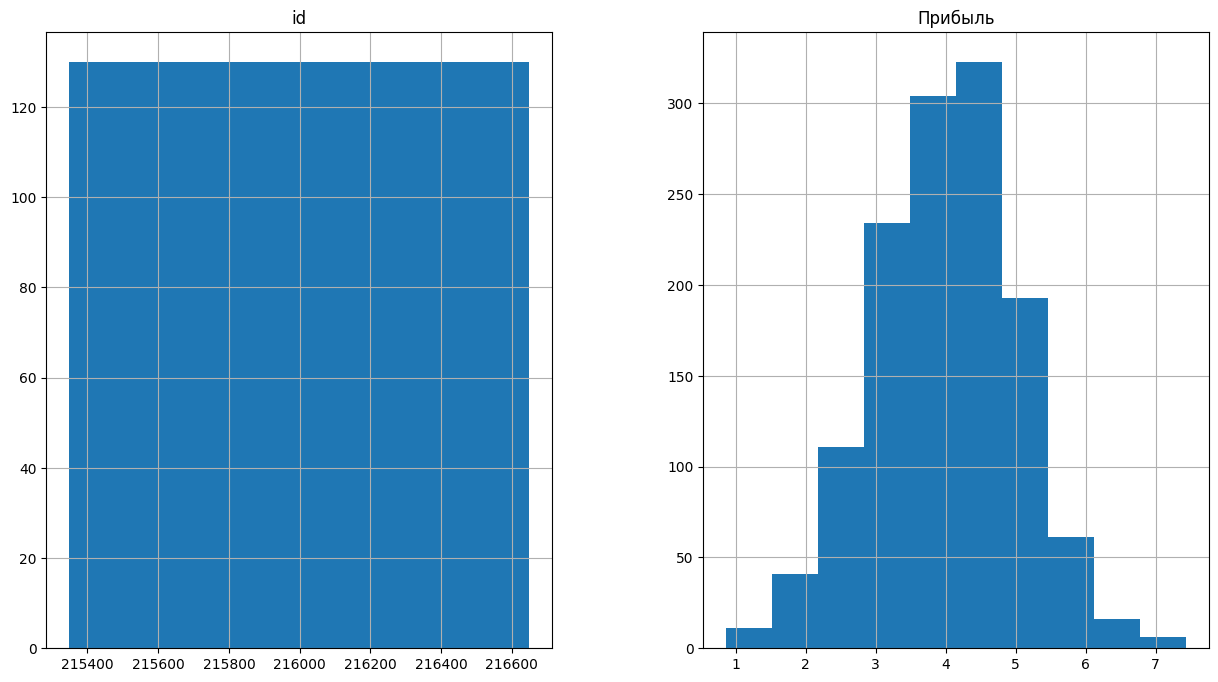

In [14]:
money = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\Анализ пользовательской активности\money (1).csv", sep = ';', decimal = ',')
general_information(money)

Видим, что:
- Столбцы имеют корректный тип столбцов 
- Прибыль распределяется нормально

### Итог первичного анализа датасетов:
- Нужно переименовать столбцы
- Нужно заменить тип столбцов где это необходимо
- Нужно проверить корректность всех значений
- Нужно проверить датасеты на дубликаты

## Предобработка датасетов

Предобработка пройдёт в несколько этапов:
1) Переименование столбцов

2) Замена типа столбца

3) Проверка на дубликаты

4) Проверка сомнительных значений которые могут быть некорректными

### Для начала переименуем столбцы в соответствии с стандартом pep8

In [17]:
print(market_file.columns)
print(market_money.columns)
print(market_time.columns)
print(money.columns)

Index(['id', 'Покупательская активность', 'Тип сервиса', 'Разрешить сообщать',
       'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
       'Акционные_покупки', 'Популярная_категория',
       'Средний_просмотр_категорий_за_визит',
       'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
       'Страниц_за_визит'],
      dtype='object')
Index(['id', 'Период', 'Выручка'], dtype='object')
Index(['id', 'Период', 'минут'], dtype='object')
Index(['id', 'Прибыль'], dtype='object')


In [18]:
market_file.rename(columns={
    'id': 'id',
    'Покупательская активность': 'activity',
    'Тип сервиса': 'service_type',
    'Разрешить сообщать': 'allow_report', 
    'Маркет_актив_6_мес': 'active_last_6_months',
    'Маркет_актив_тек_мес': 'active_months',
    'Длительность': 'duration',
    'Акционные_покупки': 'promo_purchases',
    'Популярная_категория': 'popular_category',
    'Средний_просмотр_категорий_за_визит': 'avg_view_category_visit',
    'Неоплаченные_продукты_штук_квартал': 'unpaid_product_stack_quart',
    'Ошибка_сервиса': 'service error',
    'Страниц_за_визит': 'page_visit'
}, inplace=True)

market_money.rename(columns={
    'id': 'id',
    'Период': 'period_revenue',
    'Выручка': 'revenue'
}, inplace=True)

market_time.rename(columns={
    'id': 'id',
    'Период': 'period',
    'минут': 'min'
}, inplace=True)

money.rename(columns={
    'id': 'id',
    'Прибыль': 'profit'
}, inplace=True)

In [19]:
print(market_file.columns)
print(market_money.columns)
print(market_time.columns)
print(money.columns)

Index(['id', 'activity', 'service_type', 'allow_report',
       'active_last_6_months', 'active_months', 'duration', 'promo_purchases',
       'popular_category', 'avg_view_category_visit',
       'unpaid_product_stack_quart', 'service error', 'page_visit'],
      dtype='object')
Index(['id', 'period_revenue', 'revenue'], dtype='object')
Index(['id', 'period', 'min'], dtype='object')
Index(['id', 'profit'], dtype='object')


Теперь все стобцы записаны правильно, ничего не потеряли и не забыли

In [20]:
print(market_file.columns)
print(market_money.columns)
print(market_time.columns)
print(money.columns)

Index(['id', 'activity', 'service_type', 'allow_report',
       'active_last_6_months', 'active_months', 'duration', 'promo_purchases',
       'popular_category', 'avg_view_category_visit',
       'unpaid_product_stack_quart', 'service error', 'page_visit'],
      dtype='object')
Index(['id', 'period_revenue', 'revenue'], dtype='object')
Index(['id', 'period', 'min'], dtype='object')
Index(['id', 'profit'], dtype='object')


In [21]:
market_file.rename(columns={
    'id': 'id',
    'Покупательская активность': 'activity',
    'Тип сервиса': 'service_type',
    'Разрешить сообщать': 'allow_report', 
    'Маркет_актив_6_мес': 'active_last_6_months',
    'Маркет_актив_тек_мес': 'active_months',
    'Длительность': 'duration',
    'Акционные_покупки': 'promo_purchases',
    'Популярная_категория': 'popular_category',
    'Средний_просмотр_категорий_за_визит': 'avg_view_category_visit',
    'Неоплаченные_продукты_штук_квартал': 'unpaid_product_stack_quart',
    'Ошибка_сервиса': 'service error',
    'Страниц_за_визит': 'page_visit'
}, inplace=True)

market_money.rename(columns={
    'id': 'id',
    'Период': 'period_revenue',
    'Выручка': 'revenue'
}, inplace=True)

market_time.rename(columns={
    'id': 'id',
    'Период': 'period',
    'минут': 'min'
}, inplace=True)

money.rename(columns={
    'id': 'id',
    'Прибыль': 'profit'
}, inplace=True)

In [22]:
print(market_file.columns)
print(market_money.columns)
print(market_time.columns)
print(money.columns)

Index(['id', 'activity', 'service_type', 'allow_report',
       'active_last_6_months', 'active_months', 'duration', 'promo_purchases',
       'popular_category', 'avg_view_category_visit',
       'unpaid_product_stack_quart', 'service error', 'page_visit'],
      dtype='object')
Index(['id', 'period_revenue', 'revenue'], dtype='object')
Index(['id', 'period', 'min'], dtype='object')
Index(['id', 'profit'], dtype='object')


In [14]:
market_file['promo_purchases'].unique()

array(['0.0', '0.75', '0.14', '0.99', '0.94', '0.26', '0.23', '0.17',
       '0.13', '0.35', '0.74', '0.29', '0.98', '0.95', '0.22', '0.4',
       '0.24', '0.21', '0.39', '0.9', '0.89', '0.27', '0.33', '0.34',
       '0.32', '0.93', '0.3', '0.28', '0.31', '0.25', '0.36', '0.16',
       '0.11', '0.2', '0.18', '0.15', '0.6', '0.12', '0.19', '0.44',
       '0.47', '0.91'], dtype=object)

Никаких анамалий не замечено, просто поменяем тип столбца

In [23]:
market_file['active_last_6_months'] = market_file['active_last_6_months'].astype('float')
market_file['promo_purchases'] = market_file['promo_purchases'].astype('float')
market_money['revenue'] = market_money['revenue'].astype('float')

Проверим данные по выручке

In [24]:
market_money.describe()

,id,revenue
count,3900.000000,3900.000000
mean,215997.500000,5025.696051
std,375.325686,1777.704104
min,215348.000000,0.000000
25%,215672.750000,4590.150000
50%,215997.500000,4957.500000
75%,216322.250000,5363.000000
max,216647.000000,106862.200000


In [25]:
market_file['active_last_6_months'] = market_file['active_last_6_months'].astype('float')
market_file['promo_purchases'] = market_file['promo_purchases'].astype('float')
market_money['revenue'] = market_money['revenue'].astype('float')

In [26]:
market_money = market_money.loc[market_money['revenue'] < 100000]

### Проверим датасеты на дубликаты

In [27]:
print(market_file.duplicated().sum())
print(market_money.duplicated().sum())
print(market_time.duplicated().sum())
money.duplicated().sum()

0
0
0


np.int64(0)

Полные дубликаты отсутсвуют

In [28]:
market_file['id'].duplicated().sum()

np.int64(0)

Неявные дубликаты тоже отсутствуют

In [29]:
print(market_file.duplicated().sum())
print(market_money.duplicated().sum())
print(market_time.duplicated().sum())
money.duplicated().sum()

0
0
0


np.int64(0)

In [30]:
market_file['service_type'].unique()

array(['премиум', 'стандартт', 'стандарт'], dtype=object)

Исправим опечатку

In [31]:
market_file.loc[market_file['service_type'] == 'стандартт', 'service_type'] = 'стандарт'

### Проверим на корректность значения столбца с Средний_просмотр_категорий_за_визит 

In [32]:
market_file['avg_view_category_visit'].unique()

array([6, 4, 5, 3, 2, 1])

С ним всё хорошо

### Исправим опечатку в третьем датасете

In [33]:
market_time.loc[market_time['period'] == 'предыдцщий_месяц', 'period'] = 'предыдущий_месяц'


In [34]:
market_time.head(2)

,id,period,min
0,215348,текущий_месяц,14
1,215348,предыдущий_месяц,13


Теперь всё прекрасно!

## Исследовательский анализ данных

In [35]:
market_time.loc[market_time['period'] == 'предыдцщий_месяц', 'period'] = 'предыдущий_месяц'


### Создадим функцию для построения интерактивный боксплот для делального изучения столбцов с числами в датасете


### Первый датасет

*Выберем столбцы из первого датасета для визуализации, нам подойдут числовые типы столбцов, с неноманальными данными*

In [36]:
columns = ['active_last_6_months', 'duration', 'promo_purchases', 'unpaid_product_stack_quart', 'page_visit']

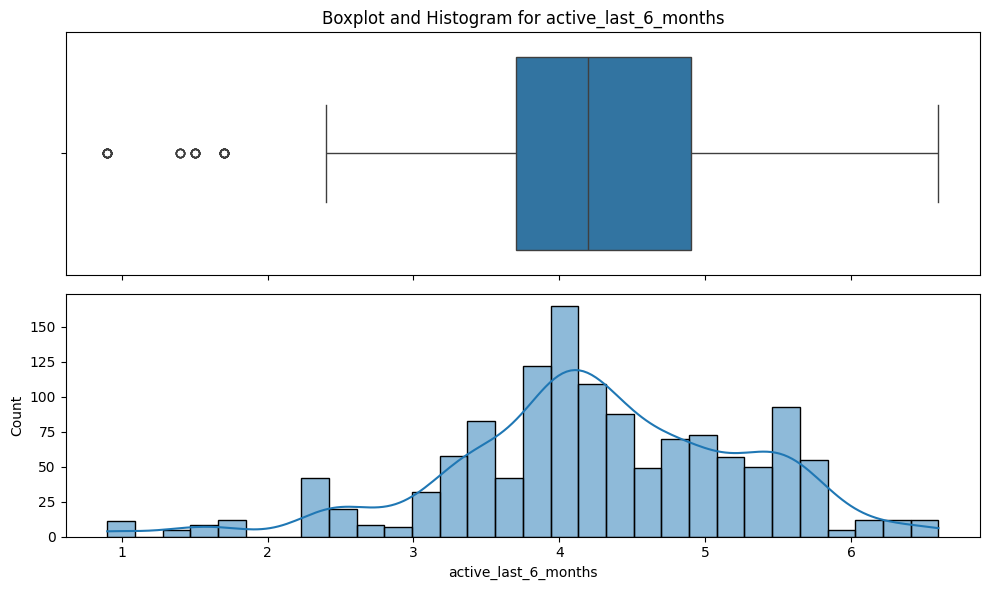

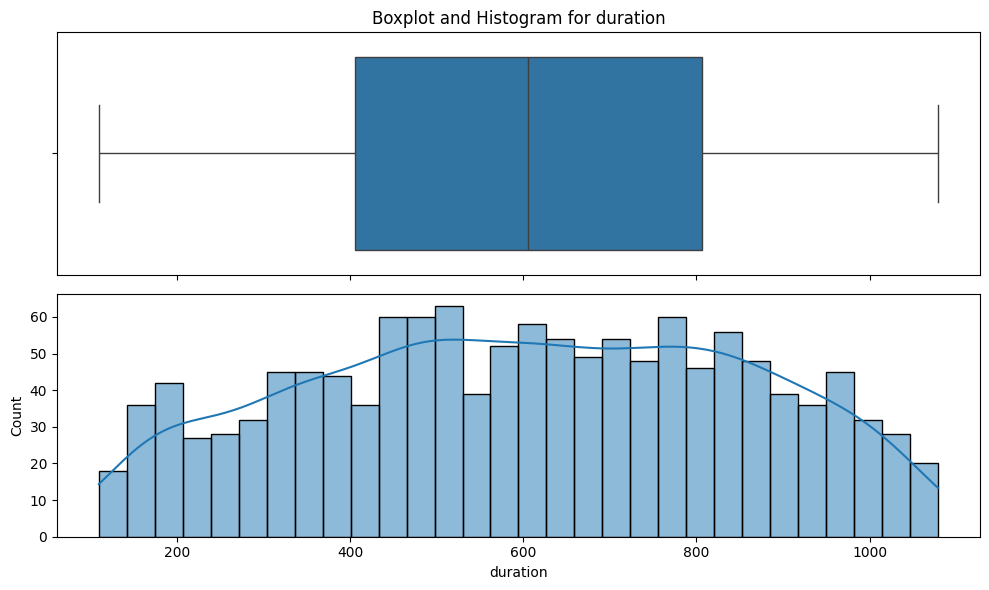

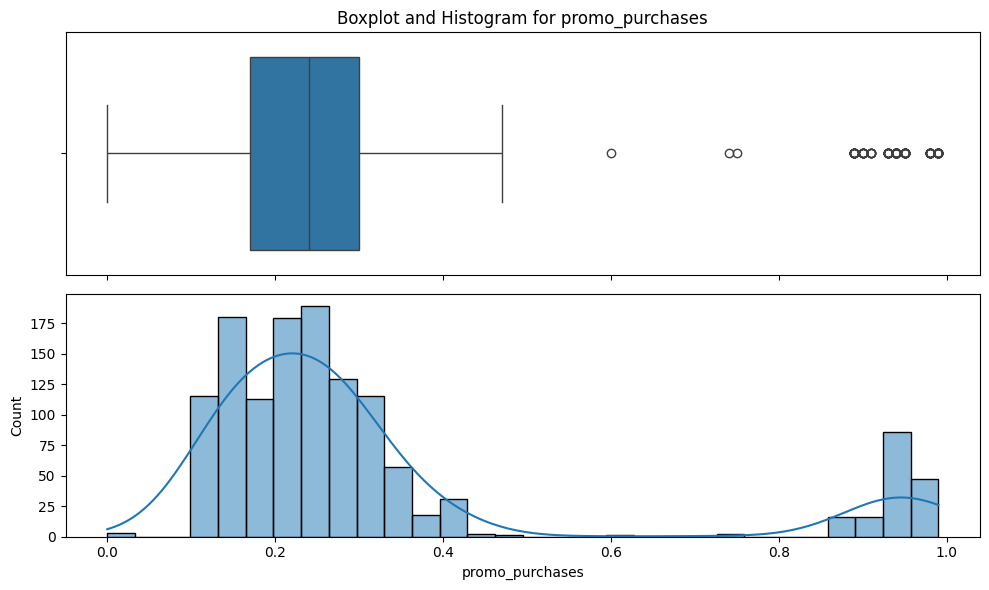

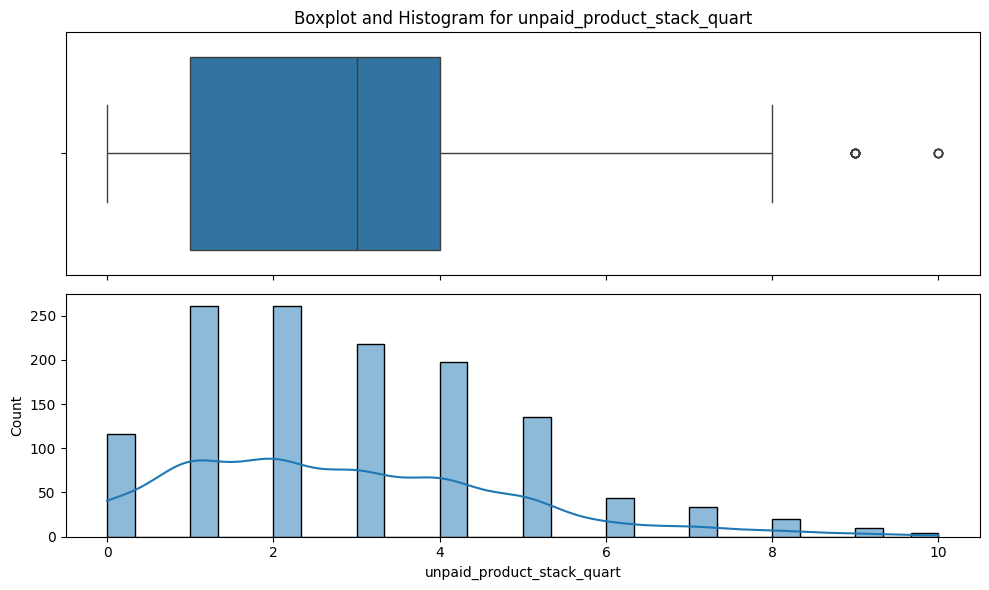

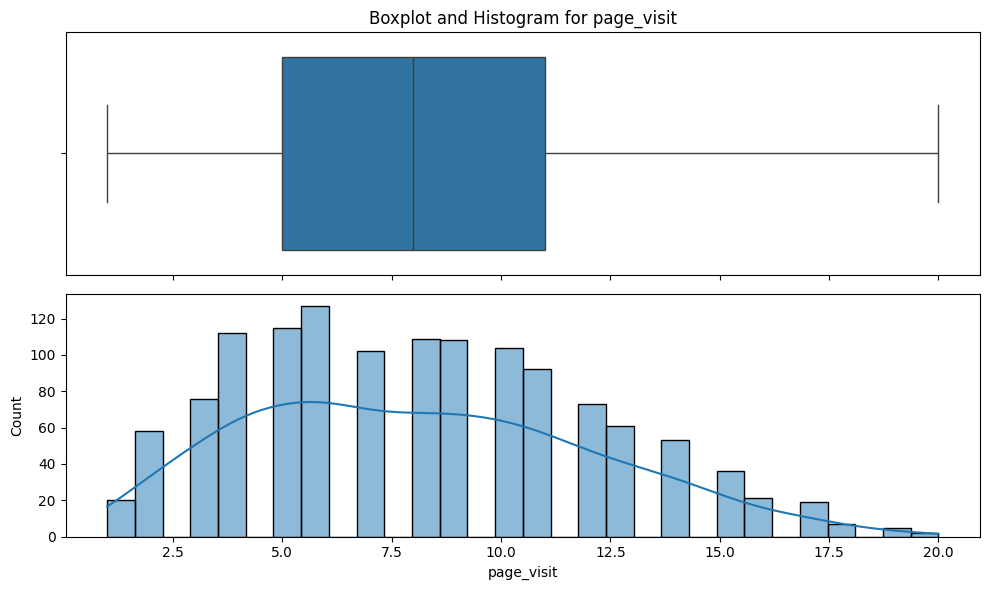

In [37]:
def px_box(data, column):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10, 6))
       
       # Создание боксплота
    sns.boxplot(data=data, x=column, ax=ax_box)
       
       # Создание гистограммы
    sns.histplot(data[column], ax=ax_hist, bins=30, kde=True)
       
    ax_box.set_title(f'Boxplot and Histogram for {column}')
    ax_box.set(xlabel='')
    ax_hist.set(xlabel=column)
       
    plt.tight_layout()
    plt.show()

   # Пример использования
for column in columns:
    px_box(market_file, column)

Из Исследовательского анализа видно:
- active_last_6_months имеет несколько выбросов, это редкие случаи когда у сервиса не получилось коммуницировать с пользователем для привлечения клиента и увиличения заинтересованности у клиента  
- Все значения duration распределяются равномерно, выбросов не обнаруженно
- promo_purchases имеет несколько выбросов, из наблюдения можно выяснить что пользователи делятся на 2 кластера, у которых акционных покупок доля от 0.1 до 0.4 (Пользователи не ориентируются на акции, выбирают по потребности, качеству или только в определённой категории товаров), а так же у которых доля акционных покупок близка к 1 (покупают почти исключительно акционные товары) их и определили как выбросы
- unpaid_product_stack_quart тоже имеет выбросы, это означает, что пользователей с количеством товаров в корзине который не оплачивали 3 месяца очень редко превышает 8 шт.
- 'page_visit распределяется почти нормально, анамалий не обнаруженно



*Теперь выберем столбы с категориальными значениями и числовыми номинальными*

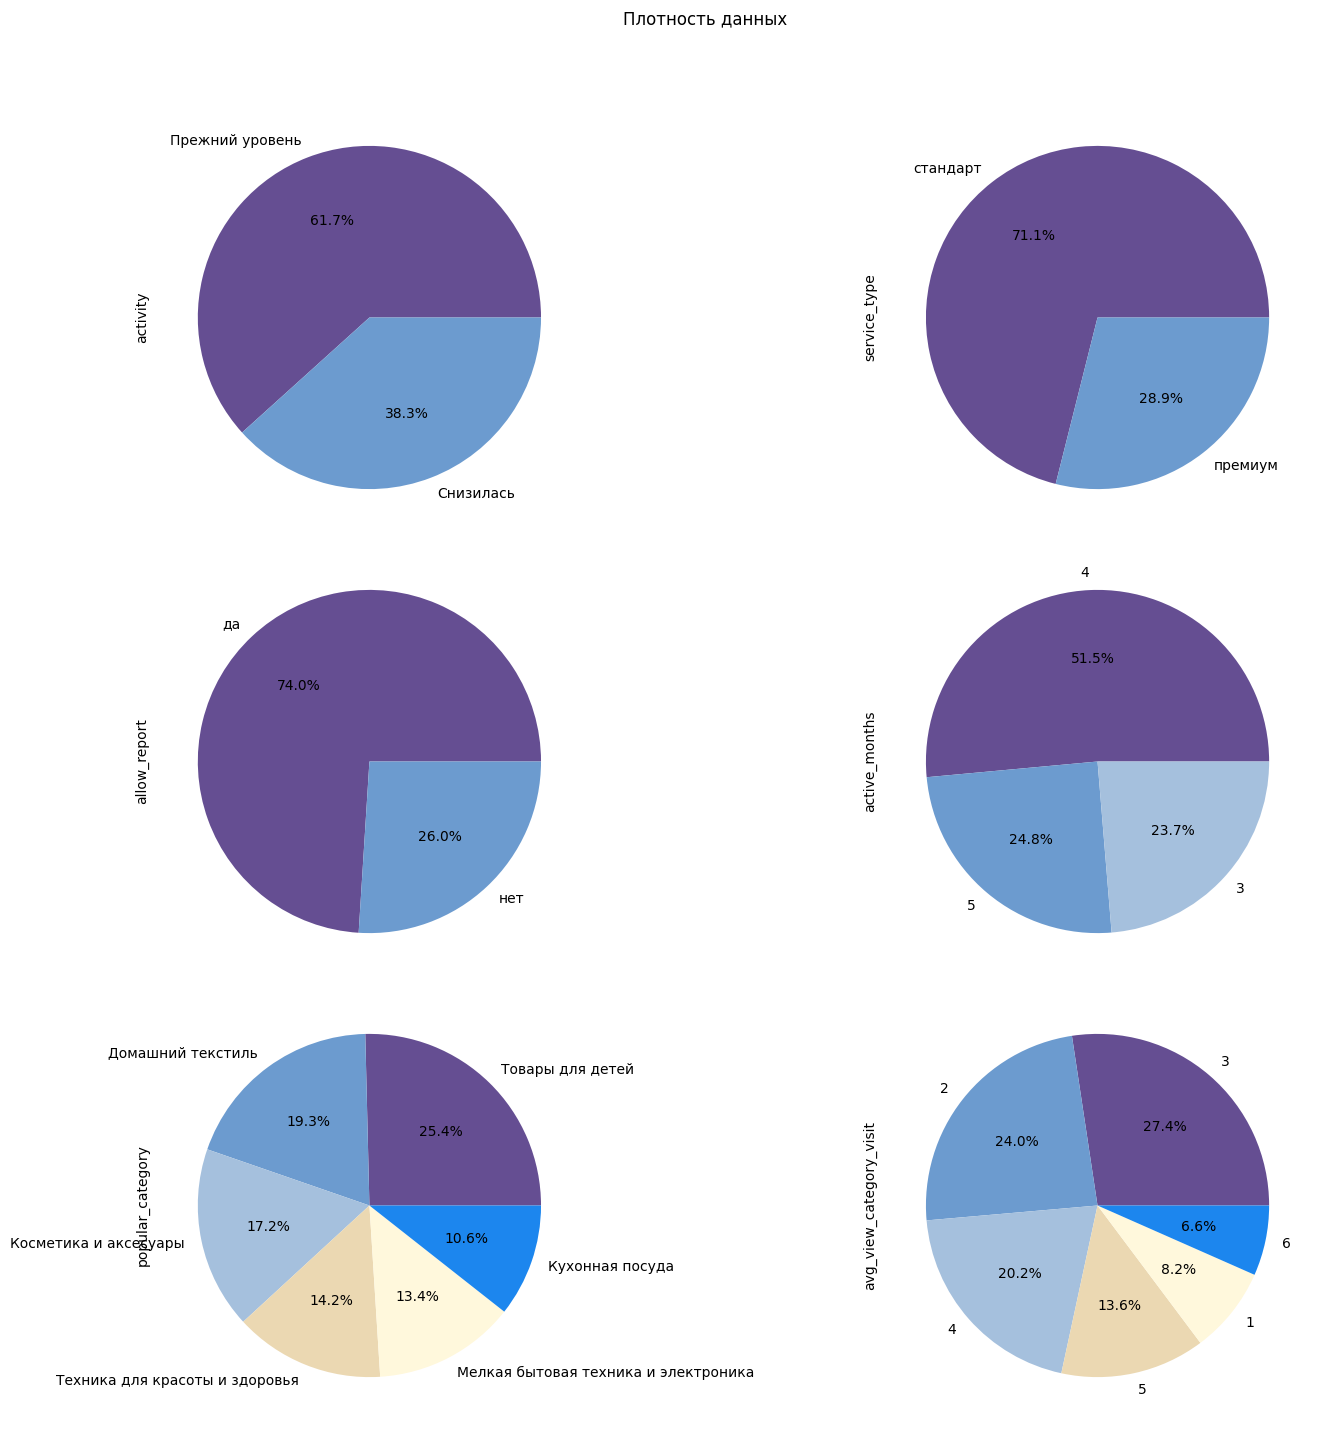

In [38]:
columns = ['activity', 'service_type', 'allow_report', 'active_months', 
           'popular_category', 'avg_view_category_visit']
# для столбца с кол-вом сбоев подберём другой график из-за большого кол-ва значений
pastel_colors = ['#654E92', '#6C9BCF', '#A5C0DD', '#EBD8B2', '#FFF8DC', '#1C86EE']

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Плотность данных')
axs = axs.flatten()

for i, column in enumerate(columns):
    market_file[column].value_counts().plot(kind='pie', ax=axs[i], colors=pastel_colors, autopct='%1.1f%%')
    axs[i].set_ylabel(column)  

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()


Можем определить что:
- Большая часть пользователей поддерживают свою активность (61,7%)
- Большая часть пользователей имеет стандартную подписку (71,1%)
- Большая часть пользователей разрешила отправлять доп рассылку (74%)
- 50% датасета с пользователями которые 4 раза коммуницировали с сервисом дополнительно, и почти одинаковое кол-во 5 или 3 раза
- Самая популярная категория товаров это - Товары для детей (25,4%), Самая непопулярная - кухонная посуда (10,6%)
- в среднем чаще всего за везил пользователь смотрит 3 различные категории товаров (27,4%), чуть реже 2 категории (24%), очень редко по 6 и по 1 категорий, 6,6% и 8,2% соответственно 

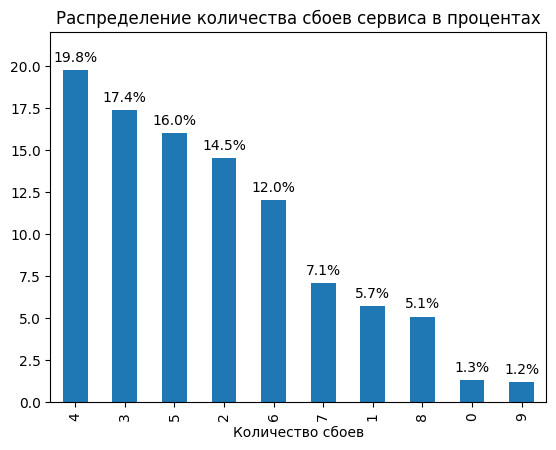

In [39]:
percentages = market_file['service error'].value_counts(normalize=True) * 100

# Строим столбчатую диаграмму
percentages.plot(kind='bar')

# Настраиваем заголовок и метки
plt.title('Распределение количества сбоев сервиса в процентах')
plt.xlabel('Количество сбоев')
plt.ylim(0, 22)

# Добавляем процентные значения на график
for i in range(len(percentages)):
    plt.text(i, percentages.iloc[i] + 0.5, f'{percentages.iloc[i]:.1f}%', ha='center')

plt.show()

По распределению кол-ва сбоев которые были у пользователя, чаще всего происходило от 2 до 6 сбоев и очень редко 0 или 9

### Второй датасет

Для начала посмотрим распределение по столбцу с выручкой

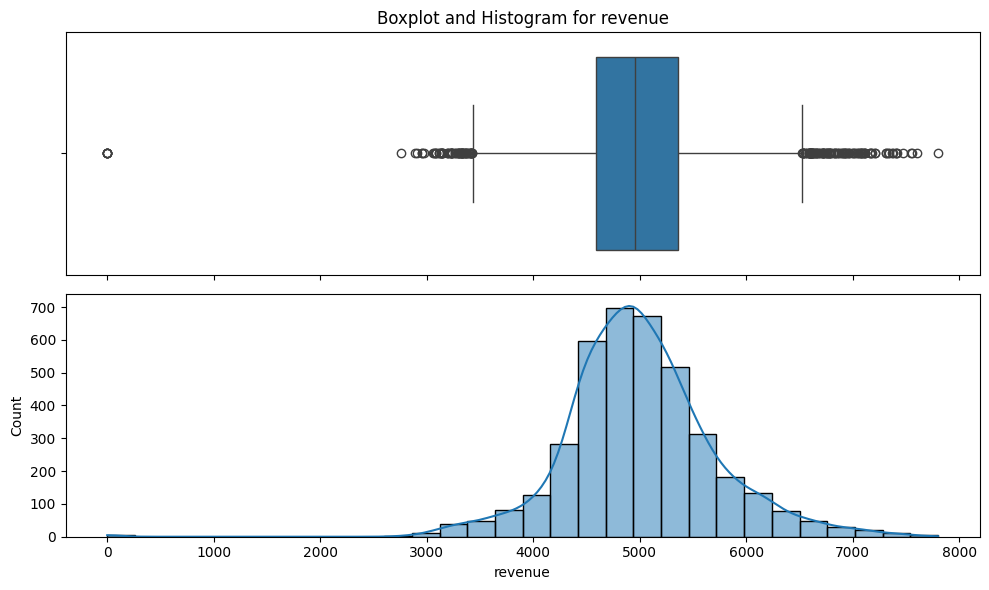

In [40]:
px_box(market_money, 'revenue')

Помним, что прибыли делится на несколько периодов, значит могут быть частные случаи когда пользователь не делал покупки или же делал оптовую закупку. Это мы можем определить как выбросы на графике, в среднем выручка колеблется от 3500 до 6500, распределение нормальное

теперь посмотрим на распределение выручки в разных периодах

Text(0, 0.5, 'Кол-во значений')

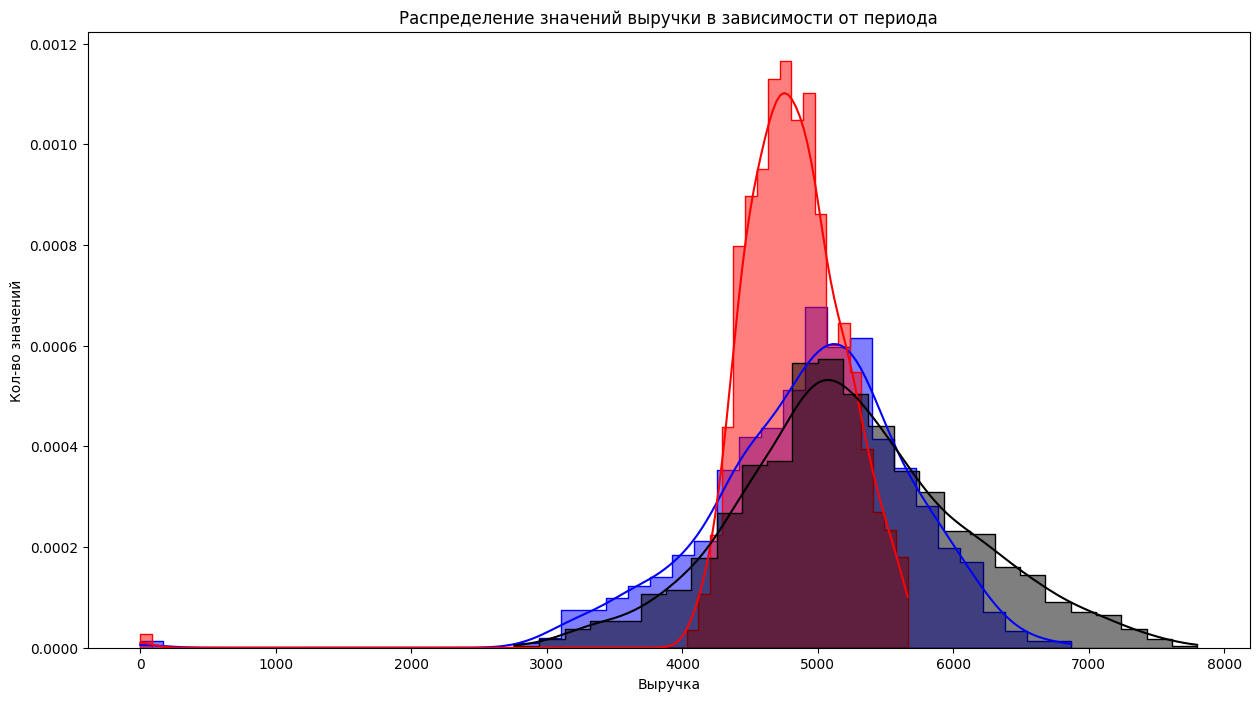

In [41]:
plt.figure(figsize=(15, 8))
df = market_money.pivot_table(index='id', columns='period_revenue', values='revenue')
sns.histplot(data=df, x='предыдущий_месяц', kde=True, element='step', stat='density', color="blue")
sns.histplot(data=df, x='препредыдущий_месяц', kde=True, element='step', stat='density', color="red")
sns.histplot(data=df, x='текущий_месяц', kde=True, element='step', stat='density', color='black')
plt.title('Распределение значений выручки в зависимости от периода')
plt.xlabel('Выручка')
plt.ylabel('Кол-во значений')

Видим что распределение нормальное, за предпредидущий период все пользователи внесли выручку в размере близком 5000, вероятно это был какой-то праздник (нг, 8 марта, 23 февраля и т.д.)

Теперь посмотрим на столбец с периодом

<Axes: ylabel='count'>

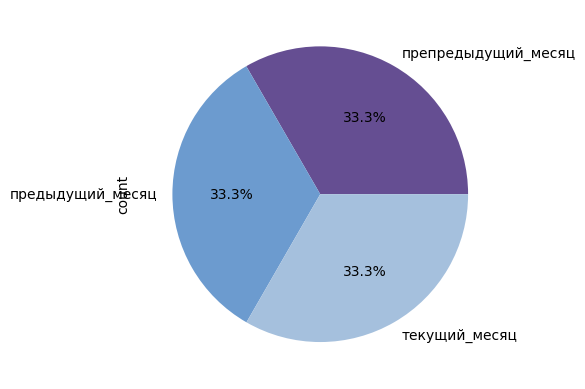

In [42]:
market_money['period_revenue'].value_counts().plot(kind='pie', colors=pastel_colors, autopct='%1.1f%%')

Видим, что все периоды занимают одинаковые доли, значит по каждому id есть вся отчётность за 3 месяца по отдельности

### Третий датасет

Исследуем третий датасет, начнём с столбца с продолжительностью

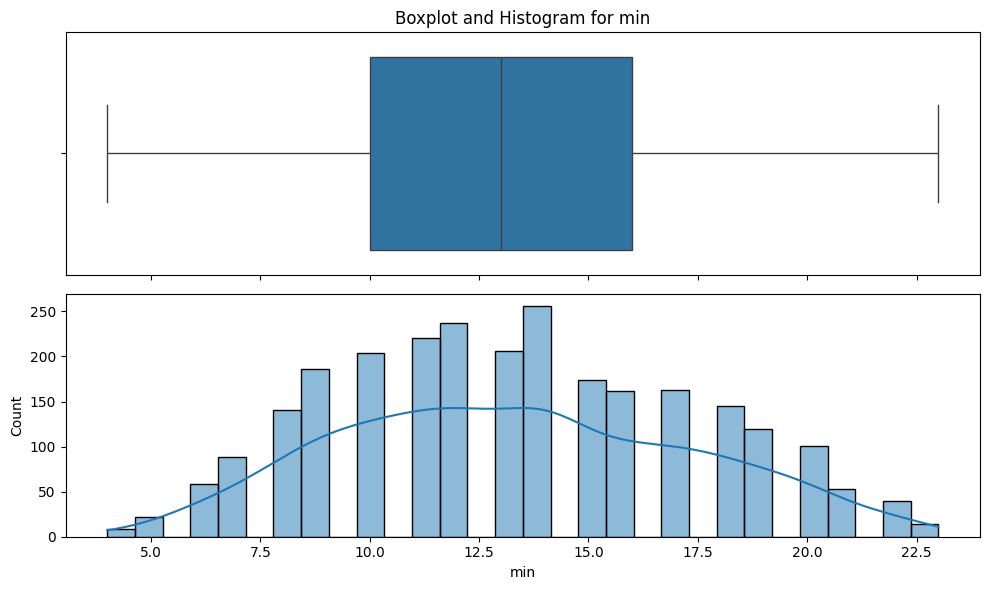

In [43]:
px_box(market_time, 'min')

Продолжительность за один период в среднем длится от 10 до 16 минут, распределение близкое к нормальному, выбросов не обнаружено

<Axes: ylabel='count'>

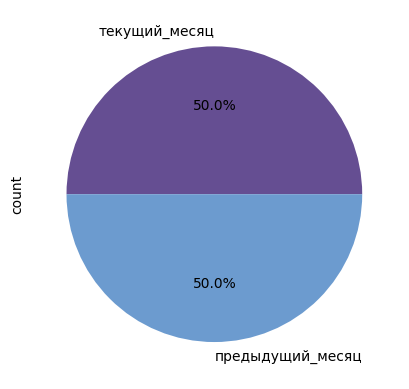

In [44]:
market_time['period'].value_counts().plot(kind='pie', colors=pastel_colors, autopct='%1.1f%%')

Периодов в датасете всего два и они имеют одинаковые доли в датасете

### Четвёртый датасет

В последнем датасете только один столбец с числовыми значениями, рассмотрим его

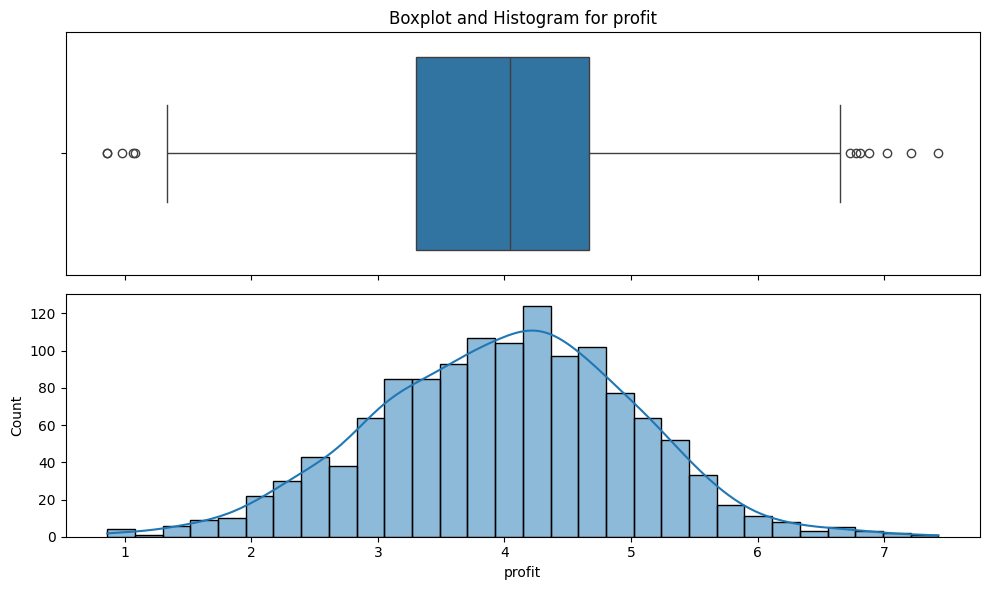

In [45]:
px_box(money, 'profit')

Выручка распределяется равномерно, есть некоторые выбросы, это частные случаи когда пользователи делали незначительные покупки или наоборот сильно большие

Итог исследовательского анализа:
- Все данные реалистичны, есть несколько выбросов, но это частные случаи, поэтому они нам нужны и мы от них не избавимся
- При построении графика  для promo_purchases, обнаружили что значения расходятся на два кластера

## Объединение таблиц

Перед обьединением преобразуем второй и третий датасет, сделаем разбение на периоды не в одном столбце а по разным столбцам, аналогично с прибылью и продолжительностью

In [46]:
market_money_1 = pd.DataFrame()
market_money_1['id'] = market_money['id']
market_money_1 = market_money_1.drop_duplicates(subset=['id'], keep='first') 
market_money['revenue_period_before_last_month'] = market_money.loc[
    market_money['period_revenue'] == 'препредыдущий_месяц', 'revenue']
market_money['revenue_period_last_month'] = market_money.loc[
    market_money['period_revenue'] == 'предыдущий_месяц', 'revenue']
market_money['revenue_period_current_month'] = market_money.loc[
    market_money['period_revenue'] == 'текущий_месяц', 'revenue']
columns = ['id', 'revenue_period_before_last_month', 'revenue_period_last_month', 'revenue_period_current_month']
market_money_1 = market_money_1.merge(market_money[columns], on='id', how='left')


In [47]:
market_money_1 = market_money_1.groupby('id').agg({
    'revenue_period_before_last_month': 'max',
    'revenue_period_last_month': 'max',
    'revenue_period_current_month': 'max'
}).reset_index()
market_money = market_money_1
#после преобразования датасет выглядит так 
market_money.head(3)

,id,revenue_period_before_last_month,revenue_period_last_month,revenue_period_current_month
0,215348,0.0,0.0,3293.1
1,215349,4472.0,5216.0,4971.6
2,215350,4826.0,5457.5,5058.4


Преобразуем третий датасет

In [48]:
market_time_1 = pd.DataFrame()
market_time_1['id'] = market_time['id']
market_time_1 = market_time_1.drop_duplicates(subset=['id'], keep='first') 
market_time['min_period_last_month'] = market_time.loc[
    market_time['period'] == 'предыдущий_месяц', 'min']
market_time['min_period_current_month'] = market_time.loc[
    market_time['period'] == 'текущий_месяц', 'min']
columns = ['id', 'min_period_last_month', 'min_period_current_month']
market_time_1 = market_time_1.merge(market_time[columns], on='id', how='left')
market_time_1 = market_time_1.groupby('id').agg({
    'min_period_last_month': 'max',
    'min_period_current_month': 'max'
}).reset_index()
market_time = market_time_1
#после преобразования датасет выглядит так 
market_time.head(3)

,id,min_period_last_month,min_period_current_month
0,215348,13.0,14.0
1,215349,12.0,10.0
2,215350,8.0,13.0


Обьединим датасеты `market_file`, `market_money`, `market_time` в единый по столбцу с id в `market_file`

In [49]:
df = market_file.merge(market_money, on='id', how='left')
df = df.merge(market_time, on='id', how='left')
df.dropna(inplace=True)
row = df.loc[df['revenue_period_before_last_month'] == 0.0].index
df.drop(row, inplace=True)
print(df.loc[df['revenue_period_last_month'] == 0.0].index)
print(df.loc[df['revenue_period_current_month'] == 0.0].index)
df.head(5)

Index([], dtype='int64')
Index([], dtype='int64')


,id,activity,service_type,allow_report,active_last_6_months,active_months,duration,promo_purchases,popular_category,avg_view_category_visit,unpaid_product_stack_quart,service error,page_visit,revenue_period_before_last_month,revenue_period_last_month,revenue_period_current_month,min_period_last_month,min_period_current_month
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12.0,10.0
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8.0,13.0
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11.0,13.0
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8.0,11.0
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10.0,10.0


Видим, что обьединение прошло успешно!

## Коррелляционный анализ

### Проведём корреляционный анализ для всех столбцов, и посмотрим как они влияют друг на друга и по отношению к столбцу с активностью

Начнём с матрици корреляций Phik

interval columns not set, guessing: ['active_last_6_months', 'active_months', 'duration', 'promo_purchases', 'avg_view_category_visit', 'unpaid_product_stack_quart', 'service error', 'page_visit', 'revenue_period_before_last_month', 'revenue_period_last_month', 'revenue_period_current_month', 'min_period_last_month', 'min_period_current_month']


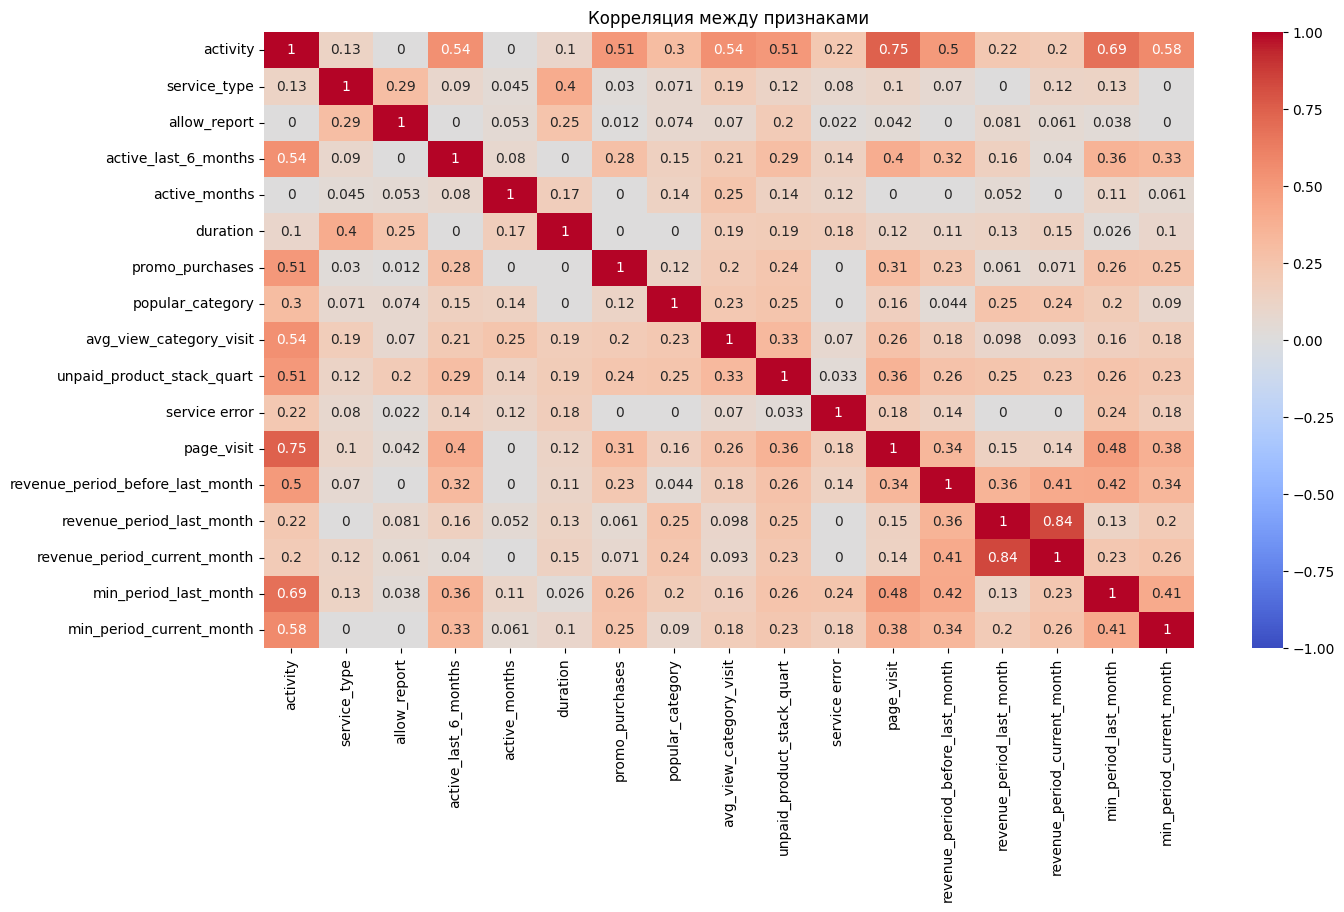

In [50]:
df1 = df.drop('id', axis=1)
df1_phik_matrix = df1.phik_matrix()
plt.figure(figsize=(15, 8))
sns.heatmap(df1_phik_matrix, annot=True, cmap='coolwarm', vmin=-1)
plt.title('Корреляция между признаками')
plt.show()

На матрице корелляции мы можем обнаружить, что:
- revenue_period_before_last_month с promo_purchases и revenue_period_last_month имеею сильную корреляционную связь
- activity имеет сильную корреляционную связь с page_visit и min_period_last_month

In [41]:
#for i in range(len(df1.columns)):
#    for j in range(i + 1, len(df1.columns)):
#        if abs(df1.phik_matrix().iloc[i, j]) > 0.8:
#            print(f"Признаки '{df1.columns[i]}' и '{df1.columns[j]}' могут быть мультиколлинеарны.")

Мультиколлинеарность признаков не обнаружена, код который находится выше закоментирован с целью ускорения процеса выполнения проекта, при желании удоставериться его можно раскоментировать

### Для более детального кареляционного анализа построим паирплот в разбивке по признаку активности пользователей

<Figure size 500x500 with 0 Axes>

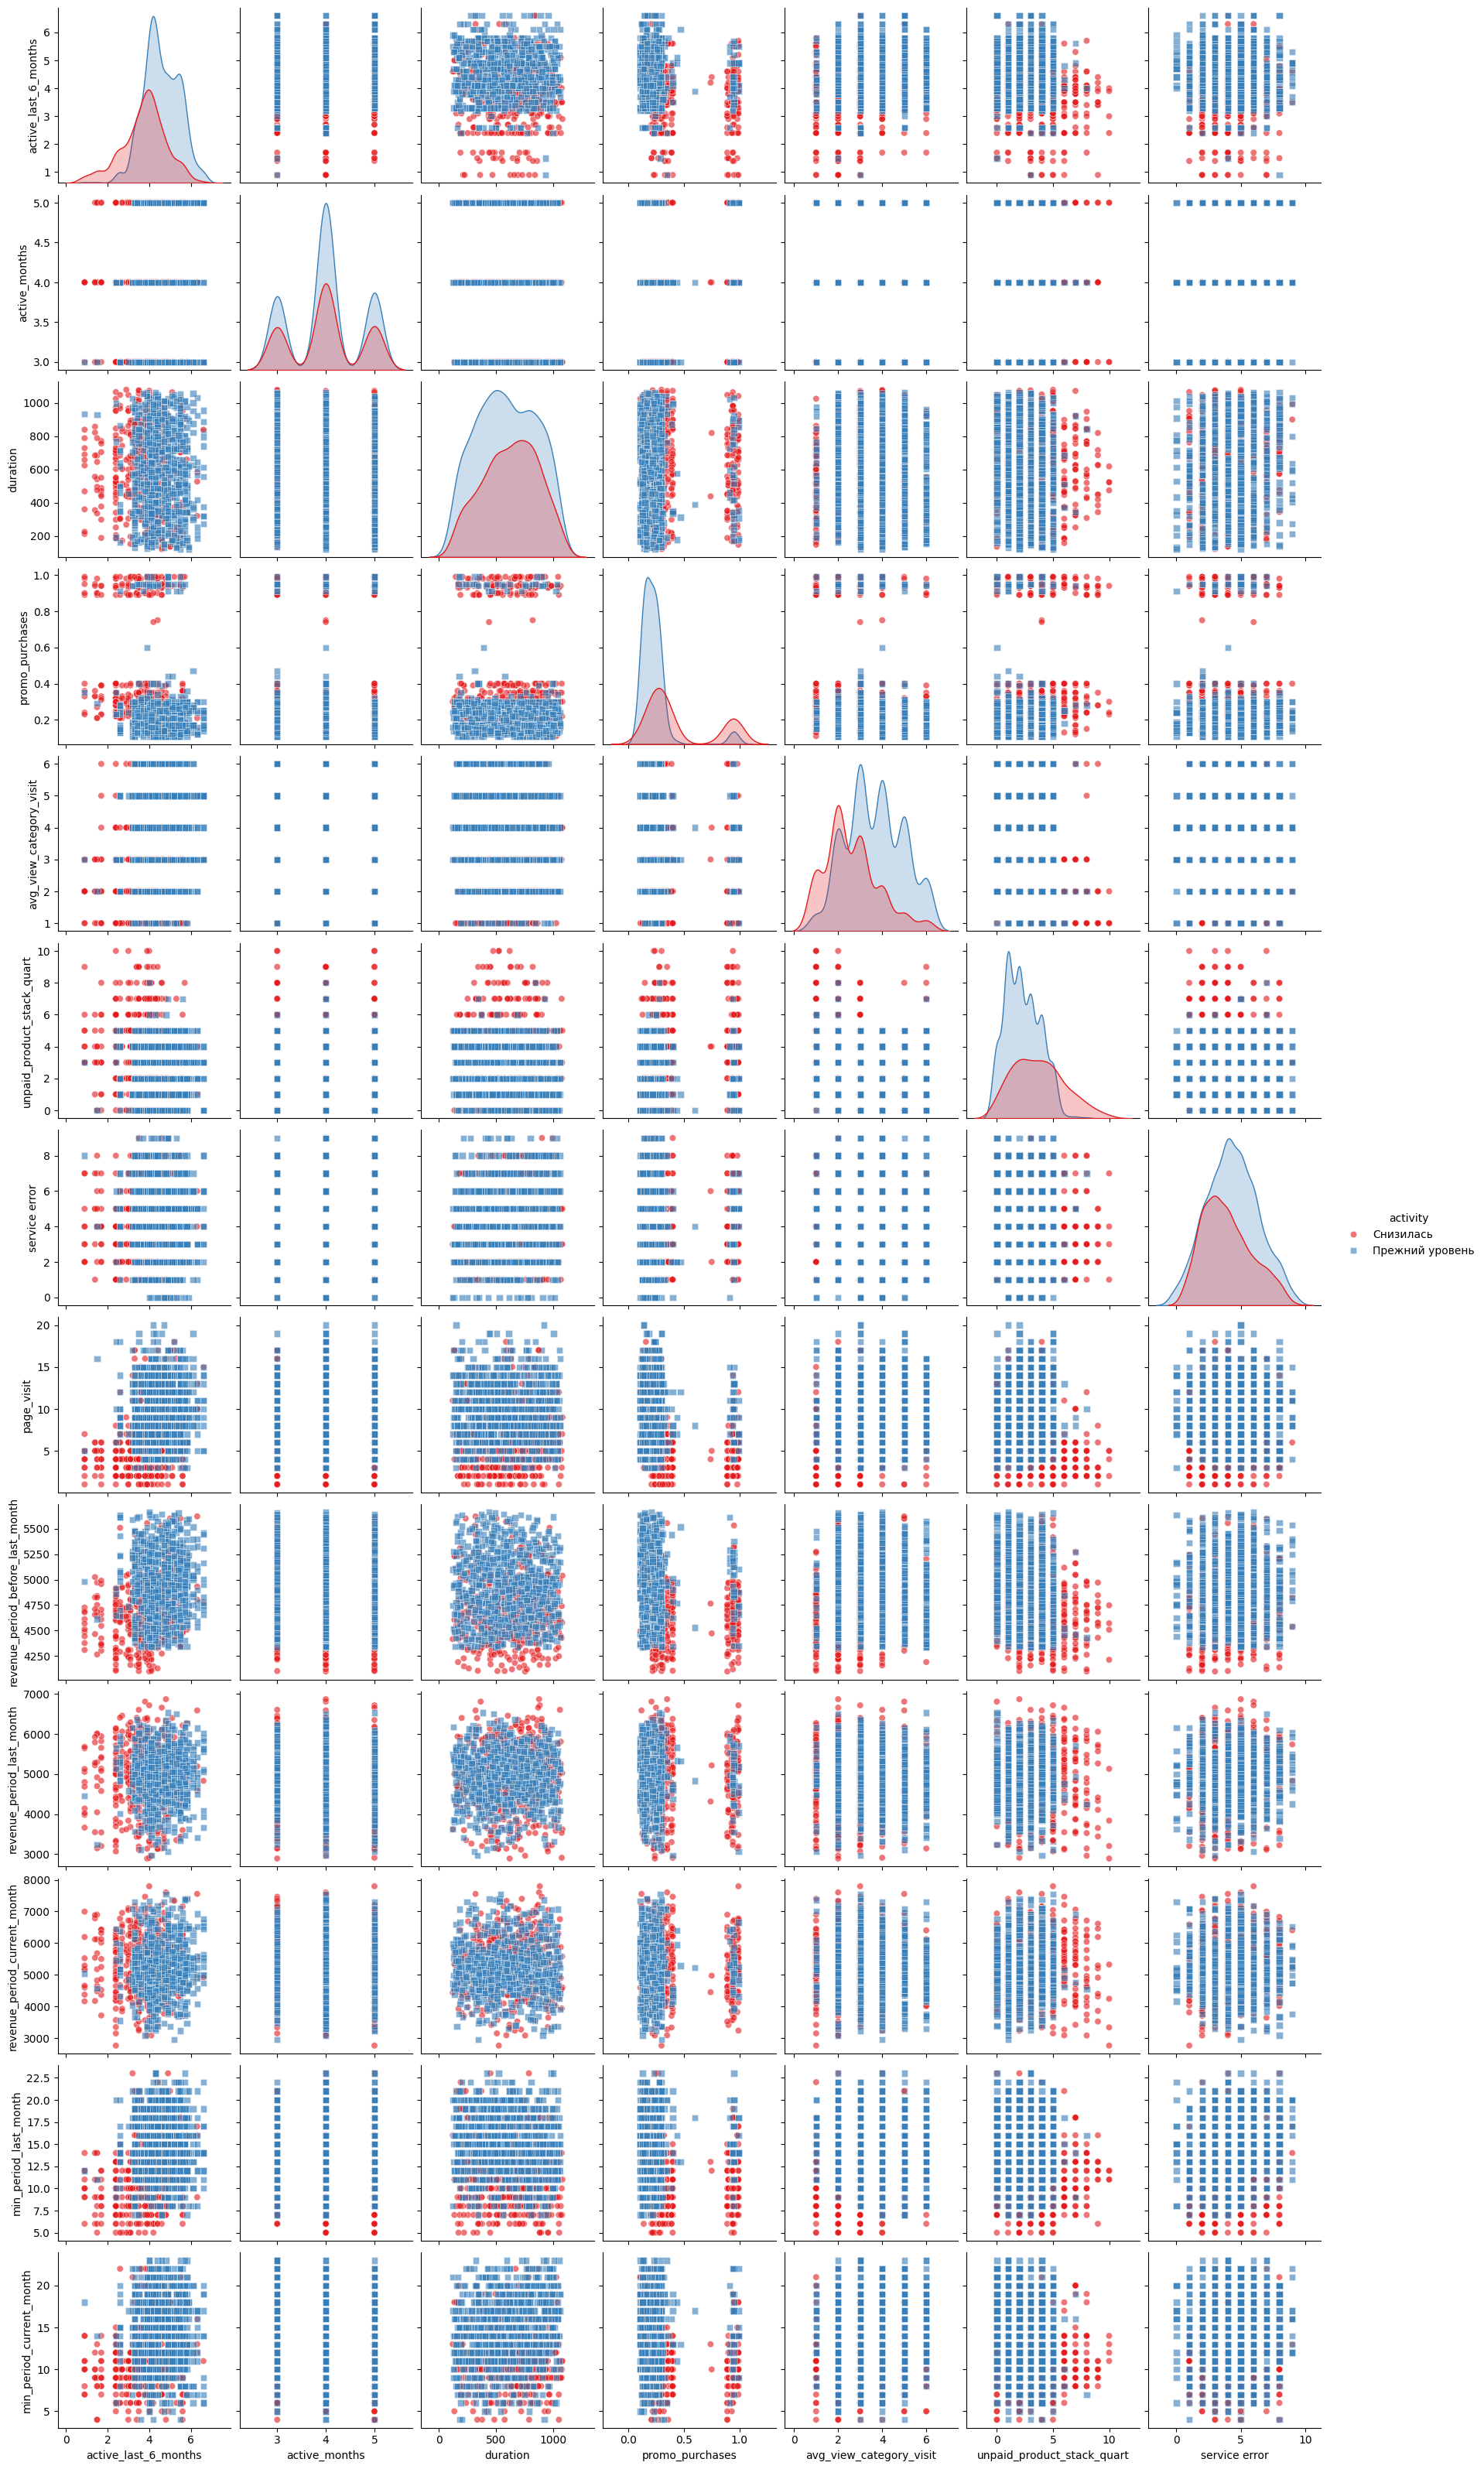

<Figure size 500x500 with 0 Axes>

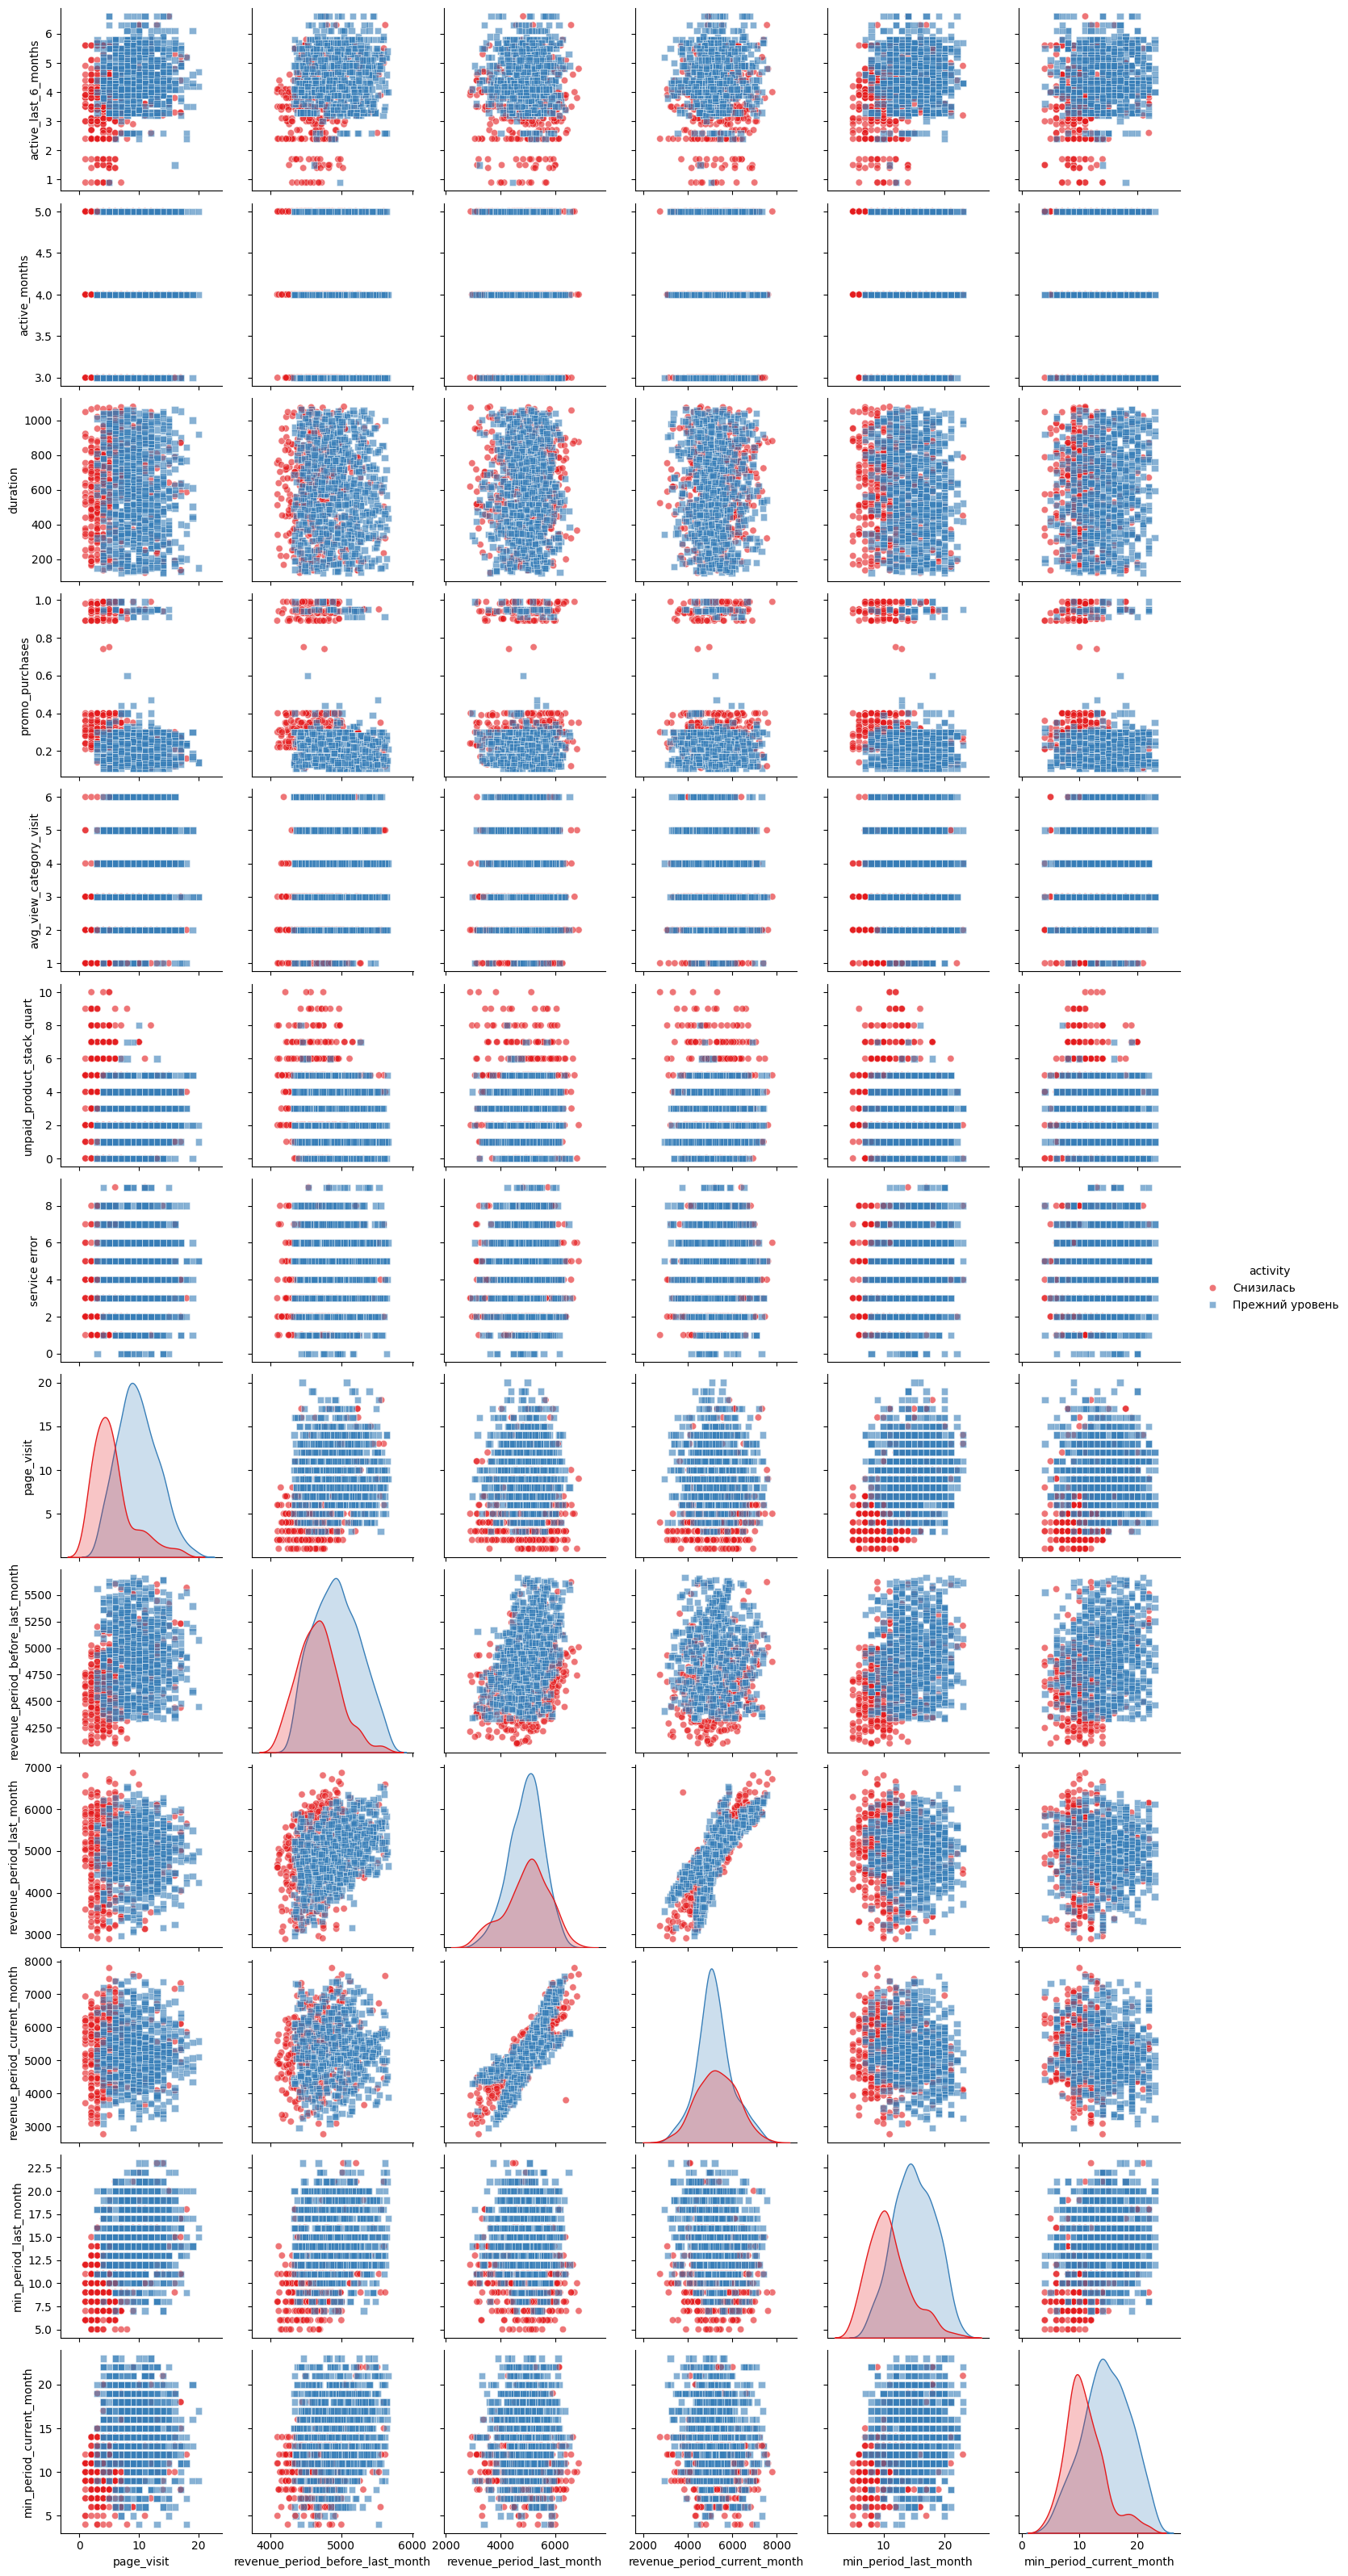

In [51]:
numeric_columns = list(df1.select_dtypes(include='number').columns)
x = numeric_columns[:7]
x1 = numeric_columns[7:]
x_x = x, x1

for i in x_x:
    plt.figure(figsize=(5, 5))
    sns.pairplot(df1, kind="scatter", hue="activity", markers=["o", "s"], palette="Set1",
            x_vars=i,
            y_vars=numeric_columns,
            plot_kws={'alpha': 0.6})
plt.show()

Итоги анализа:
- Большинство графиков показывает, что в разбивке на признак активности (Снизился/Прежний уровень) даные имеют тенденцию к кластеризацию на кластеры с определёнными границами.
- Графики с признаками описывающих продолжительность и прибыль в зависимости от периода имеют сильную линейную зависимость
- activity имеет сильную корреляционную связь с page_visit и min_period_last_month 
- Мультиколлинеарность признаков не обнаружена

## Использование пайплайнов

С Помощью пайплайнов выберем модель, её параметры и гиперпараметры, предваритель обработаем признаки с целью маштабирования и кодировки

In [52]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    df1.drop(['activity'], axis=1),
    df1['activity'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df1['activity'])

X_train.shape, X_test.shape

((972, 16), (324, 16))

Выборки полученны, кол-во столбцов совпадает

Создадим пайплайн для обработки категориальных и числовых столбцов

In [53]:
ohe_columns = ['service_type', 'popular_category']
ord_columns = ['allow_report']
num_columns = ['active_last_6_months', 'active_months', 'duration', 'promo_purchases', 'avg_view_category_visit',
              'unpaid_product_stack_quart', 'service error', 'page_visit', 'revenue_period_before_last_month', 
              'revenue_period_last_month', 'revenue_period_current_month', 'min_period_last_month', 'min_period_current_month']


In [56]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=-1, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))])
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=-1, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(categories=[['да', 'нет'],], 
                             handle_unknown='use_encoded_value', unknown_value=-1)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))])

Первые два пайплайн готовы, приступим к их соединению 

In [57]:
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough')

Создадим итоговый пайплайн

In [58]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))])

In [59]:
param_grid = [{
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__criterion': ["gini", "entropy"],
        'models__max_depth': range(2, 15),
        'models__max_features': range(2, 15),
#        'min_samples_split': range(2, 15),
#        'min_samples_leaf': range(1, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']},
        {'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 12),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']},
        {'models': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='l1')],
        'models__C': range(1,15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']},
        {'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__degree': range(1, 5),
        'models__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']}
]




In [60]:
grid_searchCV = GridSearchCV(
    pipe_final,
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    error_score='raise'
)


В качестве метрики выберем roc-auc. Эта метрика оценивает качество классификации независимо от порога классификации и хорошо подходит для сравнения моделей при несбалансированных классах, а у нас как раз не сбалансированная выборка так как отношение классов которое мы видели при исследовательском анализе равно 60-40

In [61]:
grid_searchCV.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(missing_values=-1,
                                                                                                        strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['service_type',
                                                                          'popular_cate...
                         {'models': [LogisticRegression(penalty='l1',
                                                        random_state=42,
                                                        solver='liblinear')],
                          'models__C': range(1, 15),
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']},
                         {'models': [SVC(probability=True, random_state=42)],
                          'models__degree': range(1, 5),
                          'models__kernel': ['linear', 'poly', 'rbf',
                                             'sigmoid'],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']}],
             scoring='roc_auc')

In [62]:
print('Лучшая модель и её параметры:\n\n', grid_searchCV.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_searchCV.best_score_)

# проверьте работу модели на тестовой выборке
# рассчитайте прогноз на тестовых данных
y_test_proba = grid_searchCV.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_proba)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(missing_values=-1,
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['service_type',
                                                   'popular_category']),


In [63]:
result = pd.DataFrame(grid_searchCV.cv_results_)
display(result.sort_values('rank_test_score').head(15)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models,param_models__criterion,param_models__max_depth,param_models__max_features,param_preprocessor__num,param_models__n_neighbors,param_models__C,param_models__degree,param_models__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1116,0.207202,0.007303,0.033198,0.000401,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,StandardScaler(),NaN,NaN,3.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 3, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",0.916462,0.917333,0.904505,0.910923,0.892455,0.908336,0.009171,1
1128,0.207600,0.005352,0.032200,0.000748,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,StandardScaler(),NaN,NaN,4.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 4, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",0.916462,0.917333,0.904505,0.910923,0.892455,0.908336,0.009171,1
1104,0.215196,0.005601,0.035800,0.001470,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,StandardScaler(),NaN,NaN,2.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 2, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",0.916462,0.917333,0.904505,0.910923,0.892455,0.908336,0.009171,1
1092,0.219465,0.010777,0.034200,0.001720,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,StandardScaler(),NaN,NaN,1.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 1, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",0.916462,0.917333,0.904505,0.910923,0.892455,0.908336,0.009171,1
1105,0.212792,0.004714,0.034002,0.002096,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,MinMaxScaler(),NaN,NaN,2.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 2, 'models__kernel': 'rbf', 'preprocessor__num': MinMaxScaler()}",0.901608,0.924000,0.898986,0.912500,0.870721,0.901563,0.017782,5
1129,0.213580,0.003664,0.034600,0.001020,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,MinMaxScaler(),NaN,NaN,4.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 4, 'models__kernel': 'rbf', 'preprocessor__num': MinMaxScaler()}",0.901608,0.924000,0.898986,0.912500,0.870721,0.901563,0.017782,5
1117,0.215000,0.004146,0.033600,0.001021,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,MinMaxScaler(),NaN,NaN,3.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 3, 'models__kernel': 'rbf', 'preprocessor__num': MinMaxScaler()}",0.901608,0.924000,0.898986,0.912500,0.870721,0.901563,0.017782,5
1093,0.213999,0.003284,0.036000,0.001898,"SVC(probability=True, random_state=42)",NaN,NaN,NaN,MinMaxScaler(),NaN,NaN,1.0,rbf,"{'models': SVC(probability=True, random_state=42), 'models__degree': 1, 'models__kernel': 'rbf', 'preprocessor__num': MinMaxScaler()}",0.901608,0.924000,0.898986,0.912500,0.870721,0.901563,0.017782,5
1045,0.040800,0.006882,0.017400,0.003382,"LogisticRegression(penalty='l1', random_state=42, solver='liblinear')",NaN,NaN,NaN,MinMaxScaler(),NaN,1.0,NaN,NaN,"{'models': LogisticRegression(penalty='l1', random_state=42, solver='liblinear'), 'models__C': 1, 'preprocessor__num': MinMaxScaler()}",0.895801,0.912667,0.890203,0.920158,0.872860,0.898338,0.016752,9
1072,0.056200,0.012481,0.015200,0.000980,"LogisticRegression(penalty='l1', random_state=42, solver='liblinear')",NaN,NaN,NaN,MinMaxScaler(),NaN,10.0,NaN,NaN,"{'models': LogisticRegression(penalty='l1', random_state=42, solver='liblinear'), 'models__C': 10, 'preprocessor__num': MinMaxScaler()}",0.898258,0.905778,0.887162,0.922072,0.869932,0.896640,0.017527,10


### Подведём итог применения и формирования пайплайнов:
- Лучшая модель по метрике roc-auc - SVC с параметрами: kernel=rbr, degree = от 1 до 4, скайлер для обработки данных лучше всего себя показал StandardScaler метрики качества модели показывают высокие результаты тренировочной выборке: 0.92, на тестовой выборке: 0.919


## Анализ важности признаков
Так как в топе лучших моделей находятся модели SVC и KNeighborsClassifier у нас не получится провести качественный анализ признаков в SHAP, из-за плохой адаптации и комуникации различных библиотек, будет вылезать множество ошибок, которые очень сложно исправить сохраняя исходную мысль и компактность кода, поэтому выберем наилучшую модель среди логистической регресии а уже затем оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP. 

In [66]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    df1.drop(['activity'], axis=1),
    df1['activity'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df1['activity'])

ohe_columns = ['service_type', 'popular_category']
ord_columns = ['allow_report']
num_columns = ['active_last_6_months', 'active_months', 'duration', 'promo_purchases', 'avg_view_category_visit',
              'unpaid_product_stack_quart', 'service error', 'page_visit', 'revenue_period_before_last_month', 
              'revenue_period_last_month', 'revenue_period_current_month', 'min_period_last_month', 'min_period_current_month']

ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=-1, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))])
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=-1, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(categories=[['да', 'нет'],], 
                             handle_unknown='use_encoded_value', unknown_value=-1)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))])

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough')

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='l1'))])

param_grid = [{
        'models': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='l1')],
        'models__C': range(1,15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']}]
grid_searchCV = GridSearchCV(
    pipe_final,
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    error_score='raise'
)
grid_searchCV.fit(X_train, y_train)
print('Лучшая модель и её параметры:\n\n', grid_searchCV.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_searchCV.best_score_)
y_test_proba = grid_searchCV.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_proba)}')
result = pd.DataFrame(grid_searchCV.cv_results_)
display(result.sort_values('rank_test_score').head(3)) 

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(missing_values=-1,
                                                                                 strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['service_type',
                                                   'popular_category']),


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models,param_models__C,param_preprocessor__num,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.048452,0.006708,0.016999,0.001673,"LogisticRegression(penalty='l1', random_state=42, solver='liblinear')",1,MinMaxScaler(),"{'models': LogisticRegression(penalty='l1', random_state=42, solver='liblinear'), 'models__C': 1, 'preprocessor__num': MinMaxScaler()}",0.895801,0.912667,0.890203,0.920158,0.872860,0.898338,0.016752,1
28,0.050601,0.005316,0.015599,0.000489,"LogisticRegression(penalty='l1', random_state=42, solver='liblinear')",10,MinMaxScaler(),"{'models': LogisticRegression(penalty='l1', random_state=42, solver='liblinear'), 'models__C': 10, 'preprocessor__num': MinMaxScaler()}",0.898258,0.905778,0.887162,0.922072,0.869932,0.896640,0.017527,2
31,0.053599,0.007710,0.016404,0.001019,"LogisticRegression(penalty='l1', random_state=42, solver='liblinear')",11,MinMaxScaler(),"{'models': LogisticRegression(penalty='l1', random_state=42, solver='liblinear'), 'models__C': 11, 'preprocessor__num': MinMaxScaler()}",0.898369,0.905667,0.886937,0.922297,0.869820,0.896618,0.017642,3


In [67]:
shap.initjs()

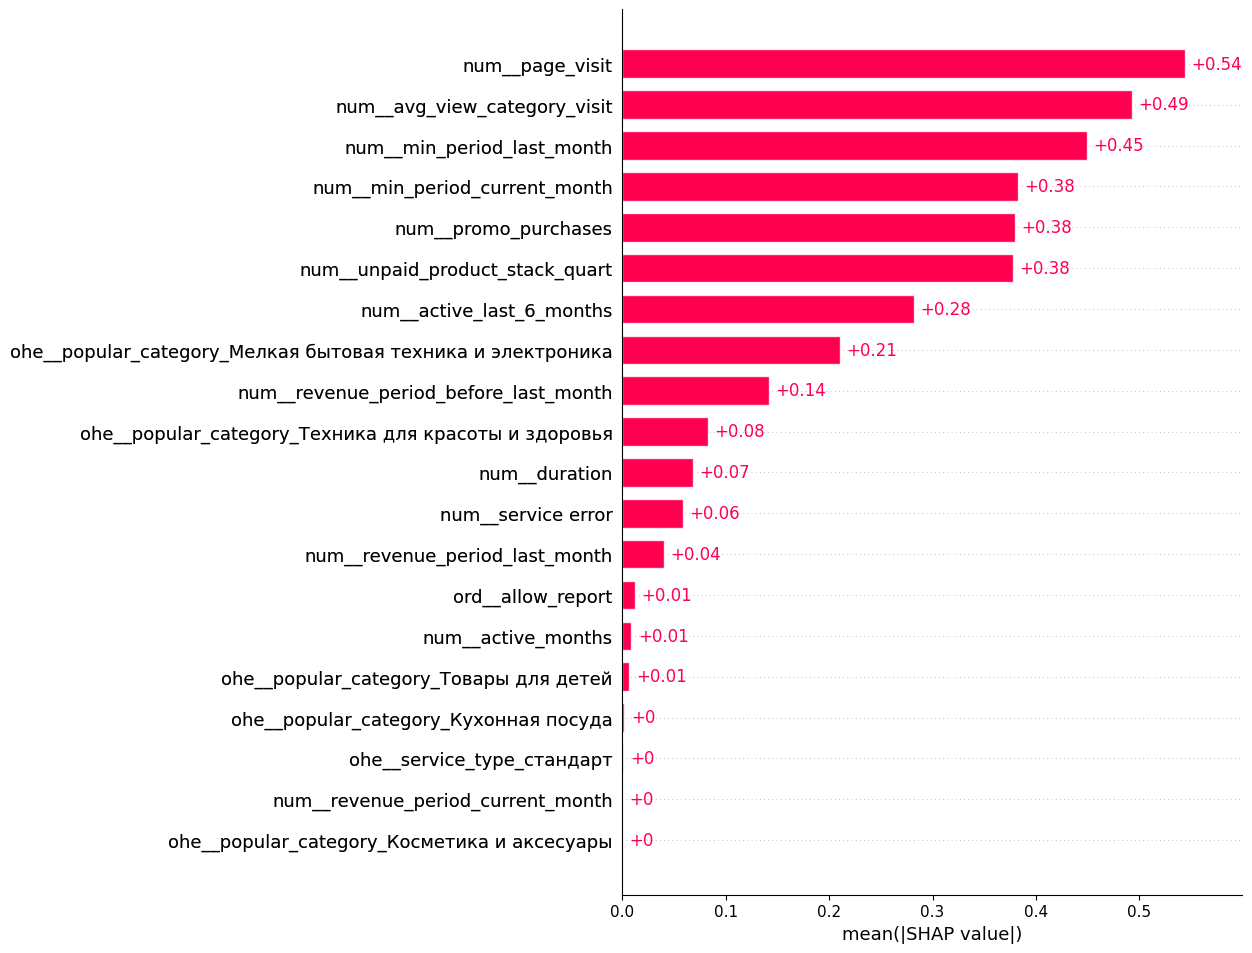

None

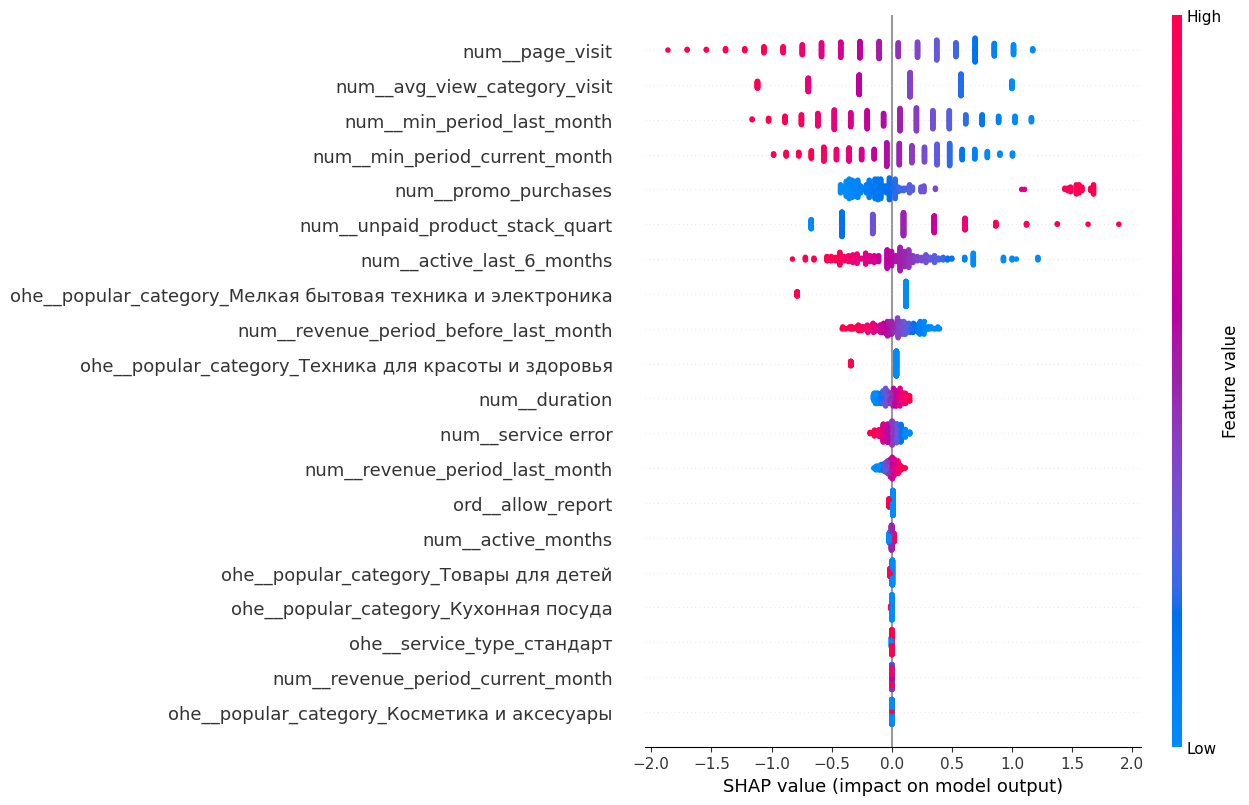

In [68]:
X_train_2 = pipe_final.named_steps['preprocessor'].fit_transform(X_train)
 
explainer = shap.Explainer(grid_searchCV.best_estimator_.named_steps['models'], X_train_2)
 
X_test_2 = pipe_final.named_steps['preprocessor'].transform(X_test)
 
feature_names = pipe_final.named_steps['preprocessor'].get_feature_names_out()

X_test_2 = pd.DataFrame(X_test_2, columns=feature_names)
 
shap_values = explainer(X_test_2)
 
display(shap.plots.bar(shap_values, max_display=22))
shap.plots.beeswarm(shap_values, max_display=22) 

In [70]:

print("Метки классов:", grid_searchCV.best_estimator_.classes_)

Метки классов: ['Прежний уровень' 'Снизилась']


Видим что shap взяла за 0 - Прежний уровень и 1 - снизилась
Итоги анализа признаков:
- Самым важным признаком оказался 'ohe__popular_category_Мелкая бытовая техника и электроника'. Если у пользователя самая популярная категория покупок техника и электроника, то с очень большой вероятностью модель класифицирует такого пользователя как у которого активнасть снизилась, это можно обьянить так: если то так то скорее всего его покупки требуют значительную часть бюджета и из-за этого он не может делать такие покупки часто, как итог интерес к сервису не падает, но снижается активнось
- Вторым по значимости признак является среднее кол-во просмотров различных категорий, чем больше категорий просмотренно, тем вероятнее что активность не снизится. 
- Третий признак ('ohe__popular_category_Техника для красоты и здоровья') аналогичен первому, но оказывает меньшее влиянее на активность, так как в наше время набирает тенденцию культура ухода для собой, что напрямую оказывает влияние на бьюти сферу и рост самозанятых, начинающих матеров, у которых нет большого бюджета на дорогую технику, или же заказываю из-за набора оборотов продаж услуг
- Четвёртый признак ('num__page_visit'), аналогичен второму признаку.
- Пятый признак ('num__promo_purchases') имеет уже среднюю значимость для модели, чем больше акционных покупок, тем скорее всего модель предскажет что у пользователя уровень покупательской активности прежний
- Шестой и седьмой признаки 'num__revenue_period_current_month', 'num__min_period_last_month', гласит о том, что чем дольше они находятся на платформе тем вероятнее их активность в качестве свершения покупок снижается, вероятнее всего аналогичен второму признаку,
- Восьмой признак ('num__unpaid_product_stack_quart') повествует нам о том что чем больше товаров в корзине тем вероятно скорее свершися покупка/покупки
- Остальные признаки модель определяет как малоинформативными, из-за плохой связи с целевым признаком, из-за большого количества шума в значениях
- Самым не важным для модели признаком оказался 'ohe__popular_category_Косметика и аксесуары', так как это никак не влияет на рост и спад активности


### Проверка

Из-за шумных и неинформативных, а так же не связанных признаков, модель может начать применять их и усложняться и переобучаться, применяя их там где этого не требуется. Удалим такие признаки, если это так то метрика выростит.

In [72]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
scaler_st = StandardScaler()
selector = SelectKBest(f_classif, k=16)
model = SVC(
    probability=True, 
    random_state=RANDOM_STATE,
    kernel='rbf',
    degree=1)
RANDOM_STATE = 42
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    df1.drop(['activity', 'allow_report', 'active_months', 'service_type', 'service error', 'duration'], axis=1),
    df1['activity'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df1['activity'])

ohe_columns = ['popular_category']
num_columns = ['active_last_6_months', 'promo_purchases', 'avg_view_category_visit',
              'unpaid_product_stack_quart', 'page_visit', 'revenue_period_before_last_month', 
              'revenue_period_last_month', 'revenue_period_current_month', 'min_period_last_month', 'min_period_current_month']

encoder.fit(X_train[ohe_columns])
encoder_ohe_columns = encoder.get_feature_names_out()
X_train[encoder_ohe_columns] = encoder.transform(X_train[ohe_columns])
X_test[encoder_ohe_columns] = encoder.transform(X_test[ohe_columns])
X_train = X_train.drop(ohe_columns, axis=1)
X_test = X_test.drop(ohe_columns, axis=1)

columns = X_train.columns
X_train = scaler_st.fit_transform(X_train)
X_test = scaler_st.transform(X_test)
model.fit(X_train, y_train)
predict_proba = model.predict_proba(X_test)[:, 1]
roc_2 = roc_auc_score(y_test, predict_proba)
print(f'Метрика ROC-AUC на тестовой выборке до удаления ненужных признаков: {roc_auc_score(y_test, y_test_proba)}')
print(f'Метрика ROC-AUC на тестовой выборке после удаления ненужных признаков: {roc_2}')


Метрика ROC-AUC на тестовой выборке до удаления ненужных признаков: 0.9182138090037617
Метрика ROC-AUC на тестовой выборке после удаления ненужных признаков: 0.9278809206002508


Метрика стала лучше почти на 1%

Подведём итог:
* 1. Повышение маркетинговой активности
- Запуск регулярных рекламных кампаний: Увеличьте частоту акций и специальных предложений (скидки, распродажи), чтобы поддерживать интерес пользователей и уменьшить вероятность снижения их активности.
- Использование E-mail маркетинга: Разработайте регулярные рассылки с акциями и новыми поступлениями, чтобы удерживать пользователей вовлеченными.

* 2. Сокращение продолжительности пользования сервисом
- Упрощение процесса регистрации и покупки: Минимизируйте шаги, необходимые для завершения покупки. Например, предоставьте возможность быстрой регистрации через социальные сети и упростите процесс оформления заказа.
- Инструменты для быстрого поиска и фильтрации: Облегчите поиск товаров с помощью эффективных фильтров и сортировок, что сократит время, необходимое пользователю для нахождения подходящих товаров.

* 3. Персонализированные предложения
- Рекомендательные алгоритмы: Чаще предлагайте пользователям товары из категорий, которые они уже просматривали, а также смежные товары (например, аксессуары к основным товарам). Используйте механизмы рекомендательных систем для улучшения персонализации.

* 4. Оптимизация количества товаров в заказе
- Введение возможностей частичной оплаты: Для всех категорий, кроме "быт.техника и электротавары", предложите пользователям возможность оплаты частями или предоплаты, чтобы снизить стресс от больших сумм и повысить вероятность завершения покупки.
- Изменение подхода к напоминаниям: Настройте автоматизированные напоминания для пользователей, оставивших товары в корзине, с предложением на ограниченные по времени скидки на эти товары.

* 5. Увеличение просмотров категорий
- Кросс-промоции: Обеспечьте возможность перехода между смежными категориями товаров, предлагая ссылки и баннеры, чтобы пользователи могли легче находить новые интересные для них товары.
- Улучшение навигации: Разработайте удобные и актуальные страницы категорий для повышения пользовательского интереса, случайные выборки или рекомендации могут помочь увеличить количество просмотренных страниц.

## Итоговый вывод

В этом проекте нам удалось подобрать модель для предсказания упадка покупательской активности с большой долей правильных прогнозов. 
Для этого мы выполнили:
* 1 При изучении датасета:
** Нужно переименовать столбцы
** Нужно заменить тип столбцов где это необходимо
** Нужно проверить корректность всех значений
** Нужно проверить датасеты на дубликаты
* 2 Предобработали данные:
** Исправили то что нашли при изучении датафреймов
* 3 Провели исследовательский анализ:
* Первый датасет
** active_last_6_months имеет несколько выбросов, это редкие случаи когда у сервиса не получилось коммуницировать с пользователем для привлечения клиента и увиличения заинтересованности у клиента
** Все значения duration распределяются равномерно, выбросов не обнаруженно
** promo_purchases имеет несколько выбросов, из наблюдения можно выяснить что пользователи делятся на 2 кластера, у которых акционных покупок доля от 0.1 до 0.4 (Пользователи не ориентируются на акции, выбирают по потребности, качеству или только в определённой категории товаров), а так же у которых доля акционных покупок близка к 1 (покупают почти исключительно акционные товары) их и определили как выбросы
** unpaid_product_stack_quart тоже имеет выбросы, это означает, что пользователей с количеством товаров в корзине который не оплачивали 3 месяца очень редко превышает 8 шт.
** 'page_visit распределяется почти нормально, анамалий не обнаруженно
* Второй датасет
** Видим, что все периоды занимают одинаковые доли, значит по каждому id есть вся отчётность за 3 месяца по отдельности
** Все значения выручки распределяются равномерно, выбрасов не обнаруженно
* Третий датасет
** Периодов в датасете всего два и они имеют одинаковые доли в датасете
** Все значения выручки распределяются равномерно, выбрасов не обнаруженно
* Четвёртый датасет
** Выручка распределяется равномерно, есть некоторые выбросы, это частные случаи когда пользователи делали незначительные покупки или наоборот сильно большие
* 4 Выполнили объединение таблиц
* 5 Корреляционный анализ:
** revenue_period_before_last_month с promo_purchases и revenue_period_last_month имеею сильную корреляционную связь
** activity имеет сильную корреляционную связь с page_visit и min_period_last_month
** Мультиколлинеарность признаков не обнаружена
*** Большинство графиков показывает, что в разбивке на признак активности (Снизился/Прежний уровень) даные имеют тенденцию к кластеризацию на кластеры с определёнными границами.
** Графики с признаками описывающих продолжительность и прибыль в зависимости от периода имеют сильную линейную зависимость
* 6 Обучили различные модели подобрали к ним лучшие параметры и выбрали из всех моделей самую лучшую с помощью пайплайна
** Лучшая модель по метрике roc-auc - SVC с параметрами: kernel=rbr, degree = от 1 до 4, скайлер для обработки данных лучше всего себя показал StandardScaler метрики качества модели показывают высокие результаты тренировочной выборке: 0.92, на тестовой выборке: 0.919
* 7 Анализ важности признаков
* Так как в топе лучших моделей находятся модели SVC и KNeighborsClassifier у нас не получится провести качественный анпализ признаков в SHAP поэтому выберем наилучшую модель среди логистической регресии а уже затем оценим важность признаков для лучшей модели и построим график важности с помощью метода SHAP.
** Самым важным признаком оказался 'ohe__popular_category_Мелкая бытовая техника и электроника'. Если у пользователя самая популярная категория покупок техника и электроника, то с очень большой вероятностью модель класифицирует такого пользователя как у которого активнасть снизилась, это можно обьянить так: если то так то скорее всего его покупки требуют значительную часть 
** Самым не важным для модели признаком оказался 'ohe__popular_category_Косметика и аксесуары', так как это никак не влияет на рост и спад активности
* 8 Сегментация покупателей
* Сегмент - Группа клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности.
** Для всех категорий важно повысить маркетинговую активность, чем она больше тем меньше вероятность снижения покупательской активности
** Для всех категорий нужно снизить продолжительность пользования сервисом, нужно адаптировать процесс пользования сервисом со стороны пользователя от начала запуска сервиса до момента покупки
** При анализе признака Средний Просмотр категорий выявленно что следует чаще предлогать различные товары из тех категорий к которым пользователь так же проявлял интерес, а также товары которые находятся в смежной тематике, например аксесуары
** При всех категорий кроме "быт.техника и электротавары" видно, что чем меньше товаров ожидает оплату, тем вероятнее что этот заказ оплатят, следовательно для этих пользователей лучше чтоб товаров было меньше, для этого можно ввести возможность предоплаты, или возможность оплаты частями, чтобы люди не боялись видеть большую сумму заказа, а так же переодически напоминать им о том, что они откладывают в корзины. про категорию "быт.техника и электротавары" можно сказать что это частный случай в этой ситуации, так как эта категорию юолее затратная чем другие и накладывает на бюджет пользователя определённый стресс и поэтому товары могут быть отложены с целью ожидания получения зп, или это срочная покупка и пользователь сразу покупает её, например сломался холодильник или плита.
** Для всех категорий видно, что чем больше страниц в одной категории просматривает тем больше вероятность того, что активность не упадёт
** Примечательно что для всех категорий пользователей, выручка месячный период в качестве признака нам говорит что чем больше сумму они тратят на все покупки за предыдущий месяц тем больше вероятность того, что активнасть упадёт
** Из признака о продолжительности пользования сервисом за месяц, видно что, чем она больше тем менее вероятно снижение активности


Рекомендации по взаимодействию с пользователями:
* 1. Повышение маркетинговой активности
- Запуск регулярных рекламных кампаний: Увеличьте частоту акций и специальных предложений (скидки, распродажи), чтобы поддерживать интерес пользователей и уменьшить вероятность снижения их активности.
- Использование E-mail маркетинга: Разработайте регулярные рассылки с акциями и новыми поступлениями, чтобы удерживать пользователей вовлеченными.

* 2. Сокращение продолжительности пользования сервисом
- Упрощение процесса регистрации и покупки: Минимизируйте шаги, необходимые для завершения покупки. Например, предоставьте возможность быстрой регистрации через социальные сети и упростите процесс оформления заказа.
- Инструменты для быстрого поиска и фильтрации: Облегчите поиск товаров с помощью эффективных фильтров и сортировок, что сократит время, необходимое пользователю для нахождения подходящих товаров.

* 3. Персонализированные предложения
- Рекомендательные алгоритмы: Чаще предлагайте пользователям товары из категорий, которые они уже просматривали, а также смежные товары (например, аксессуары к основным товарам). Используйте механизмы рекомендательных систем для улучшения персонализации.

* 4. Оптимизация количества товаров в заказе
- Введение возможностей частичной оплаты: Для всех категорий, кроме "быт.техника и электротавары", предложите пользователям возможность оплаты частями или предоплаты, чтобы снизить стресс от больших сумм и повысить вероятность завершения покупки.
- Изменение подхода к напоминаниям: Настройте автоматизированные напоминания для пользователей, оставивших товары в корзине, с предложением на ограниченные по времени скидки на эти товары.

* 5. Увеличение просмотров категорий
- Кросс-промоции: Обеспечьте возможность перехода между смежными категориями товаров, предлагая ссылки и баннеры, чтобы пользователи могли легче находить новые интересные для них товары.
- Улучшение навигации: Разработайте удобные и актуальные страницы категорий для повышения пользовательского интереса, случайные выборки или рекомендации могут помочь увеличить количество просмотренных страниц.